In [1]:
# Cell 1: Import Required Libraries

# pandas is used to load, clean and manipulate the dataset as tables, DataFrames.
import pandas as pd

# numpy is used for numerical calculations and for marking missing values as np.nan.
import numpy as np

# matplotlib is used to create all charts and visual explanations here.
import matplotlib.pyplot as plt

# train_test_split divides data into training, validation, and testing parts.
# GridSearchCV searches different Random Forest settings and selects the best combination.
# PredefinedSplit lets GridSearchCV use our own validation set instead of creating random folds.
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit

# RandomForestClassifier is the machine learning model used for heart disease prediction.
# It combines many decision trees to improve prediction stability and reduce overfitting.
from sklearn.ensemble import RandomForestClassifier

# These metrics evaluate how well the model predicts heart disease on unseen test data.
from sklearn.metrics import (
    accuracy_score,        # Measures the overall percentage of correct predictions.
    precision_score,       # Measures how many predicted disease cases were truly disease cases.
    recall_score,          # Measures how many real disease cases the model successfully found.
    f1_score,              # Combines precision and recall into one balanced score.
    confusion_matrix,      # Shows true negatives, false positives, false negatives, and true positives.
    classification_report, # Gives precision, recall, and F1-score for each class.
    roc_auc_score,         # Gives a single score for how well probabilities separate the two classes.
    roc_curve,             # Creates the values needed to draw the ROC curve.
    auc                    # Calculates the area under the ROC curve.
)

# Markdown is used to print formatted statistical definitions inside the notebook.
from IPython.display import Markdown

# Shared graph style helpers
# These helpers keep graph formatting consistent across the notebook so related plots are easier to compare.

from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "axes.grid": False
})

GRAPH_COLORS = {
    "positive": "tab:red",
    "negative": "tab:blue",
    "neutral": "gray",
    "reference": "black"
}

CLASS_NAMES = ["No disease", "Disease"]

def tidy_axis(ax, grid_axis="y"):
    """Apply the same simple formatting to plot axes."""
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

def add_note(fig, note, y=-0.02):
    """Add the same style of interpretation note under a figure."""
    fig.text(0.5, y, note, ha="center", fontsize=10)

def plot_confusion_matrix_on_ax(cm, title, ax, class_names=CLASS_NAMES):
    """Plot a confusion matrix with counts and row percentages on a supplied axis."""
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    image = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j]} patients\n{cm_percent[i, j]:.1f}%",
                ha="center",
                va="center",
                fontsize=10
            )
    return image

def plot_signed_barh_on_ax(df, feature_col, value_col, title, xlabel, ax, xlim=None):
    """Plot signed horizontal bars with shared positive/negative colours."""
    plot_df = df.copy()
    colors = [GRAPH_COLORS["positive"] if v >= 0 else GRAPH_COLORS["negative"] for v in plot_df[value_col]]
    bars = ax.barh(plot_df[feature_col], plot_df[value_col], color=colors, edgecolor="black", alpha=0.85)
    ax.axvline(0, linewidth=1.2, color=GRAPH_COLORS["reference"])
    if xlim is not None:
        ax.set_xlim(xlim)
    for bar in bars:
        width = bar.get_width()
        offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
        x_position = width + offset if width >= 0 else width - offset
        alignment = "left" if width >= 0 else "right"
        ax.text(x_position, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", ha=alignment, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    tidy_axis(ax, grid_axis="x")
    return ax


In [2]:
# Cell 2: Load the Cleveland Heart Disease Dataset

# The dataset is stored online in the UCI Machine Learning Repository.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# The raw file does not include column names, so they are manually assigned here.
column_names = [
    "age",       # Patient age in years.
    "sex",       # Patient sex: 1 = male, 0 = female.
    "cp",        # Chest pain type: 1 to 4.
    "trestbps",  # Resting blood pressure in mm Hg.
    "chol",      # Serum cholesterol in mg/dl.
    "fbs",       # Fasting blood sugar above 120 mg/dl: 1 = true, 0 = false.
    "restecg",   # Resting electrocardiographic result: 0, 1, or 2.
    "thalach",   # Maximum heart rate achieved during exercise.
    "exang",     # Exercise-induced angina: 1 = yes, 0 = no.
    "oldpeak",   # ST depression induced by exercise compared with rest.
    "slope",     # Slope of the peak exercise ST segment: 1, 2, or 3.
    "ca",        # Number of major vessels colored by fluoroscopy: 0 to 3.
    "thal",      # Thalassemia result: 3 = normal, 6 = fixed defect, 7 = reversible defect.
    "num"        # Original diagnosis: 0 = no disease, 1-4 = heart disease severity.
]

# Read the dataset into a pandas DataFrame using the assigned column names.
df = pd.read_csv(url, names=column_names)

# Print the dataset shape so we know how many rows and columns were loaded.
print("Dataset shape before cleaning:", df.shape)


Dataset shape before cleaning: (303, 14)


In [3]:
# Cell 3: Sanity check

# Showing the first 10 rows helps confirm that the dataset loaded correctly.
print("First 10 rows of the raw dataset:")

# display() shows the DataFrame in a readable table format inside the notebook.
display(df.head(10))


First 10 rows of the raw dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [4]:
# Cell 4: Inspect Raw Dataset Structure

# Print all column names to confirm the dataset columns match the expected names.
print("Column names:")
print(df.columns.tolist())

# Print the raw data types before cleaning; some columns may be object type because of '?'.
print("\nData types before cleaning:")
print(df.dtypes)

# Count missing values already recognized by pandas before replacing '?'.
print("\nMissing values before cleaning:")
print(df.isna().sum())

# Show unique target labels in the original diagnosis column.
print("\nOriginal target values in 'num':")
print(df["num"].value_counts().sort_index())


Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types before cleaning:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Original target values in 'num':
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [5]:
# Cell 5: Replace Fake Missing Values and Convert Data Types

# In this dataset, missing values are written as '?', which pandas does not automatically treat as NaN.
# "?" is replaced with np.nan, which is the standard missing value marker.
df = df.replace("?", np.nan)

# Convert each column to numeric form so mathematical operations and model training can be performed.
for col in df.columns:
# errors="coerce" changes invalid values into NaN instead of stopping the notebook with an error.
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Confirm that all columns are now numeric after conversion.
print("Data types after conversion:")
print(df.dtypes)

# Count missing values after '?' has been converted to NaN.
print("\nMissing values after converting '?':")
print(df.isna().sum())


Data types after conversion:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

Missing values after converting '?':
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [6]:
# Cell 6: Create a Binary Target Variable

# The original 'num' column has 0 for no disease and 1-4 for different disease severity levels.
# For this dataset training, all disease severity values are grouped into two classes, if it is greater than 0, heart disease present and otherwise, no heart disease present.
df["target"] = (df["num"] > 0).astype(int)

# Show examples of the original target and the new binary target side by side.
print("Original target 'num' and new binary target:")
display(df[["num", "target"]].head(10))

# Show how many patients are in each binary class.
print("\nBinary target distribution:")
print(df["target"].value_counts().sort_index())


Original target 'num' and new binary target:


,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0
5,0,0
6,3,1
7,0,0
8,2,1
9,1,1



Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [7]:
# Cell 7: Identify Impossible Numeric Values

# Age must be positive, so values less than or equal to 0 are marked as missing.
df.loc[df["age"] <= 0, "age"] = np.nan

# Resting blood pressure must be positive, so impossible values are marked as missing.
df.loc[df["trestbps"] <= 0, "trestbps"] = np.nan

# Cholesterol must be positive, so impossible values are marked as missing.
df.loc[df["chol"] <= 0, "chol"] = np.nan

# Maximum heart rate must be positive, so impossible values are marked as missing.
df.loc[df["thalach"] <= 0, "thalach"] = np.nan

# Oldpeak should not be negative here, so negative values are marked as missing.
df.loc[df["oldpeak"] < 0, "oldpeak"] = np.nan

# Print missing counts after checking to show if any impossible values were found.
print("Missing values after checking impossible numeric values:")
print(df.isna().sum())


Missing values after checking impossible numeric values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
target      0
dtype: int64


In [8]:
# Cell 8: Validate Categorical Feature Values

# This dictionary lists the allowed values for each categorical feature.
valid_categories = {
    "sex": [0, 1],          # 0 = female, 1 = male.
    "cp": [1, 2, 3, 4],     # Four chest pain categories. 1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain and 4 = Asymptomatic.
    "fbs": [0, 1],          # Fasting blood sugar indicator. 0 = False (≤ 120 mg/dl) and 1 = True  (> 120 mg/dl)
    "restecg": [0, 1, 2],   # Three resting ECG categories. 0 = Normal, 1 = ST-T wave abnormality and 2 = Left ventricular hypertrophy
    "exang": [0, 1],        # Exercise-induced angina indicator. 0 = No, 1 = Yes
    "slope": [1, 2, 3],     # Three slope categories. 1 = Upsloping, 2 = Flat and 3 = Downsloping.
    "ca": [0, 1, 2, 3],     # Valid number of colored vessels.
    "thal": [3, 6, 7]       # Valid thalassemia. 3 = Normal, 6 = Fixed defect, 7 = Reversible defect
}

# Loop through each categorical column and replace invalid categories with NaN.
for col, valid_values in valid_categories.items():
# The ~ symbol reverses the condition, so rows NOT in valid_values are selected.
    df.loc[~df[col].isin(valid_values), col] = np.nan

# Print missing counts after validating categorical columns to show newly detected invalid values.
print("Missing values after validating categorical columns:")
print(df.isna().sum())


Missing values after validating categorical columns:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
target      0
dtype: int64


In [9]:
# Cell 9: Remove Duplicate Rows

# Count duplicate patient records before removal.
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicate rows.
df = df.drop_duplicates()

# Confirm that duplicate rows have been removed.
print("Duplicate rows after removal:", df.duplicated().sum())

# Show the cleaned dataset size after duplicate removal.
print("Dataset shape after duplicate removal:", df.shape)


Duplicate rows before removal: 0
Duplicate rows after removal: 0
Dataset shape after duplicate removal: (303, 15)


In [10]:
# Cell 10: Handle Missing Values with Median and Mode Imputation

# Numeric columns are measured on numbers and continuous values.
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Categorical columns represent groups or categories.
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Fill missing numeric values with the median because the median is less affected by outliers than the mean.
# The mean can be skewed heavily by extreme values, leading to misleading imputation.
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the mode because it is the most common valid category.
# It maintains the original distribution of the dataset.
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirm that there are no missing values left before visualization.
print("Missing values after imputation:")
print(df.isna().sum())

# Save the cleaned original-scale dataset.
df.to_csv("heart_cleveland_cleaned.csv", index=False)

# Display the first rows of the cleaned dataset.
print("Cleaned dataset preview:")
display(df.head())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64
Cleaned dataset preview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [11]:
# Cell 11: Descriptive Statistics Summary

# Create a descriptive-statistics table for the numeric features in their original units.
summary_stats = df[numeric_cols].agg(["count", "mean", "median", "std", "min", "max"]).T

# Add skewness to show whether each distribution leans left or right.
summary_stats["skewness"] = df[numeric_cols].skew()

# Round values to make the table.
print("Descriptive statistics for numeric features:")
display(summary_stats.round(2))

# Show class counts and percentages for the target variable.
target_summary = df["target"].value_counts().sort_index().rename(index={0: "No disease", 1: "Disease"}).to_frame("count")
target_summary["percentage"] = (target_summary["count"] / len(df) * 100).round(2)

# Display the target summary so class balance is clear.
print("Target class distribution:")
display(target_summary)


Descriptive statistics for numeric features:


,count,mean,median,std,min,max,skewness
age,303.0,54.44,56.0,9.04,29.0,77.0,-0.21
trestbps,303.0,131.69,130.0,17.60,94.0,200.0,0.71
chol,303.0,246.69,241.0,51.78,126.0,564.0,1.14
thalach,303.0,149.61,153.0,22.88,71.0,202.0,-0.54
oldpeak,303.0,1.04,0.8,1.16,0.0,6.2,1.27


Target class distribution:


,count,percentage
target,,
No disease,164,54.13
Disease,139,45.87



### Boxplot definitions and equations

A **boxplot** summarizes the center, spread, and possible outliers for each numeric feature.

- **Median**: the middle value after sorting the data.


- **Interquartile range (IQR)**: the middle 50% of the data.
  \[
  IQR = Q3 - Q1
  \]
  where \(Q1\) is the 25th percentile and \(Q3\) is the 75th percentile.

- **Spread**: how widely values vary. In a boxplot, spread is mainly shown by the IQR and whiskers.


- **Possible outliers**: values unusually far from the middle 50% of the data.
  Using the common 1.5-IQR rule:
  \[
  Lower Bound = Q1 - 1.5(IQR)
  \]
  \[
  Upper Bound = Q3 + 1.5(IQR)
  \]
  Values below the Lower Bound or above the Upper Bound are marked as possible outliers.


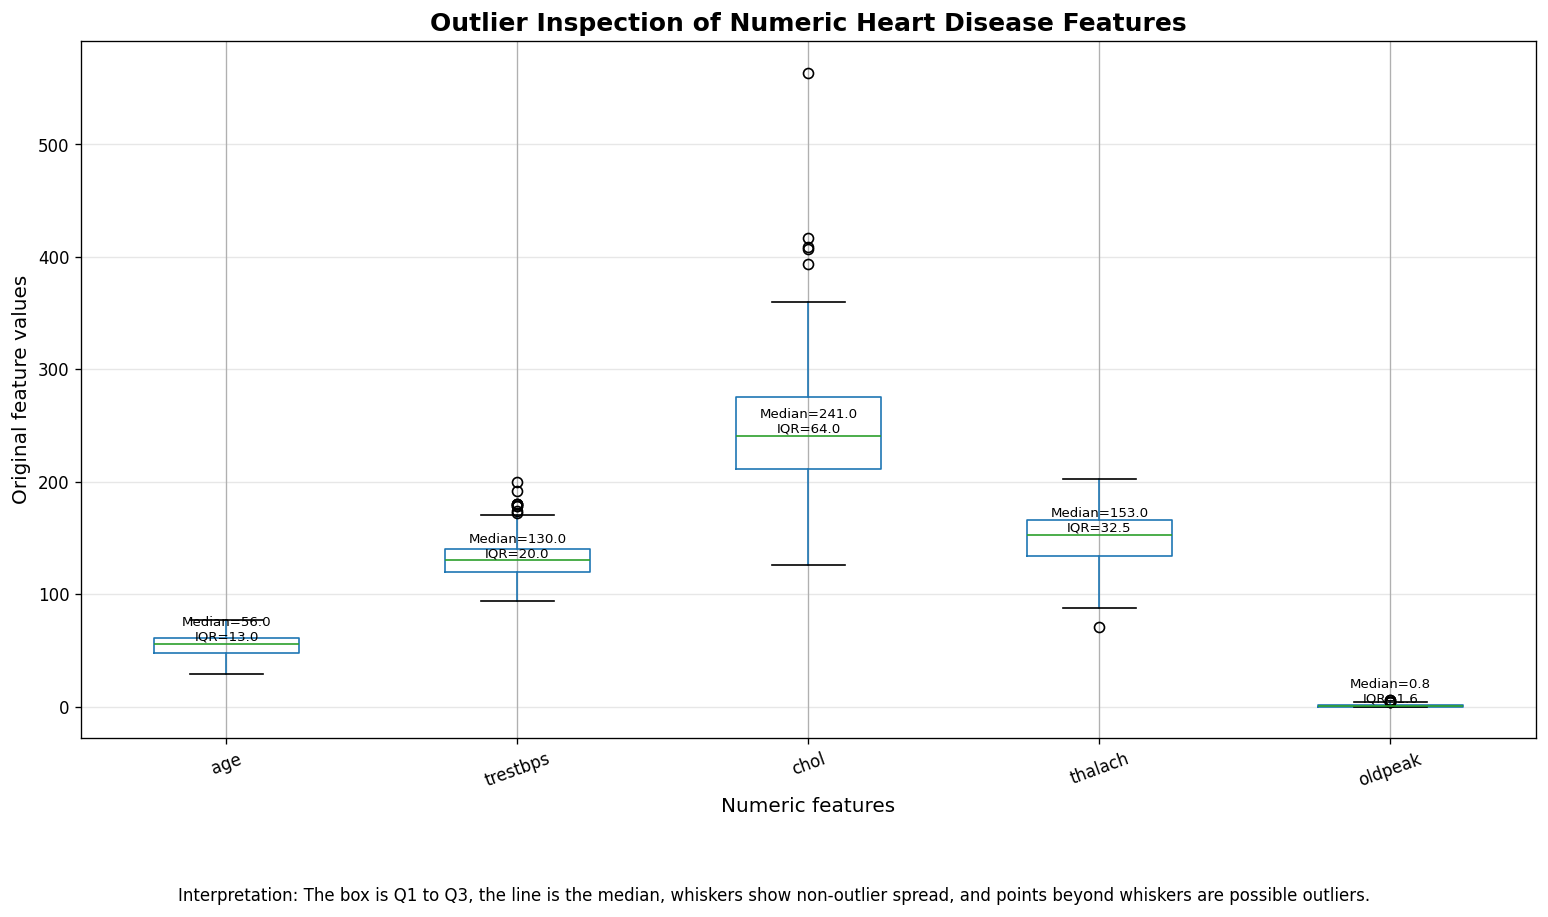

In [12]:
# Cell 12: Boxplots for Outlier Inspection
# Boxplots show the median, interquartile range, spread, and possible outliers.

# Print formal definitions and equations before the graph.
display(Markdown(r"""
### Boxplot definitions and equations

A **boxplot** summarizes the center, spread, and possible outliers for each numeric feature.

- **Median**: the middle value after sorting the data.


- **Interquartile range (IQR)**: the middle 50% of the data.
  \[
  IQR = Q3 - Q1
  \]
  where \(Q1\) is the 25th percentile and \(Q3\) is the 75th percentile.

- **Spread**: how widely values vary. In a boxplot, spread is mainly shown by the IQR and whiskers.


- **Possible outliers**: values unusually far from the middle 50% of the data.
  Using the common 1.5-IQR rule:
  \[
  Lower Bound = Q1 - 1.5(IQR)
  \]
  \[
  Upper Bound = Q3 + 1.5(IQR)
  \]
  Values below the Lower Bound or above the Upper Bound are marked as possible outliers.
"""))

# Create a wider figure so all feature names are readable.
plt.figure(figsize=(13, 7))

# Draw one boxplot per numeric feature.
box_axes = df[numeric_cols].boxplot(return_type="axes")

# Add a title.
plt.title("Outlier Inspection of Numeric Heart Disease Features", fontsize=15, fontweight="bold")

# Label the x and y axes.
plt.xlabel("Numeric features", fontsize=12)
plt.ylabel("Original feature values", fontsize=12)

# Rotate labels slightly to avoid overlap.
plt.xticks(rotation=20)

# Add a light grid to help compare values across features.
plt.grid(axis="y", alpha=0.3)

# Add median and IQR values above each feature so the center and spread are visible.
for position, col in enumerate(numeric_cols, start=1):
    median_value = df[col].median()
    q1_value = df[col].quantile(0.25)
    q3_value = df[col].quantile(0.75)
    iqr_value = q3_value - q1_value
    plt.text(
        position,
        median_value,
        f"Median={median_value:.1f}\nIQR={iqr_value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add an explanatory note under the plot.
plt.figtext(
    0.5, -0.08,
    "Interpretation: The box is Q1 to Q3, the line is the median, whiskers show non-outlier spread, and points beyond whiskers are possible outliers.",
    ha="center", fontsize=10
)

plt.tight_layout()

# Display the completed boxplot.
plt.show()


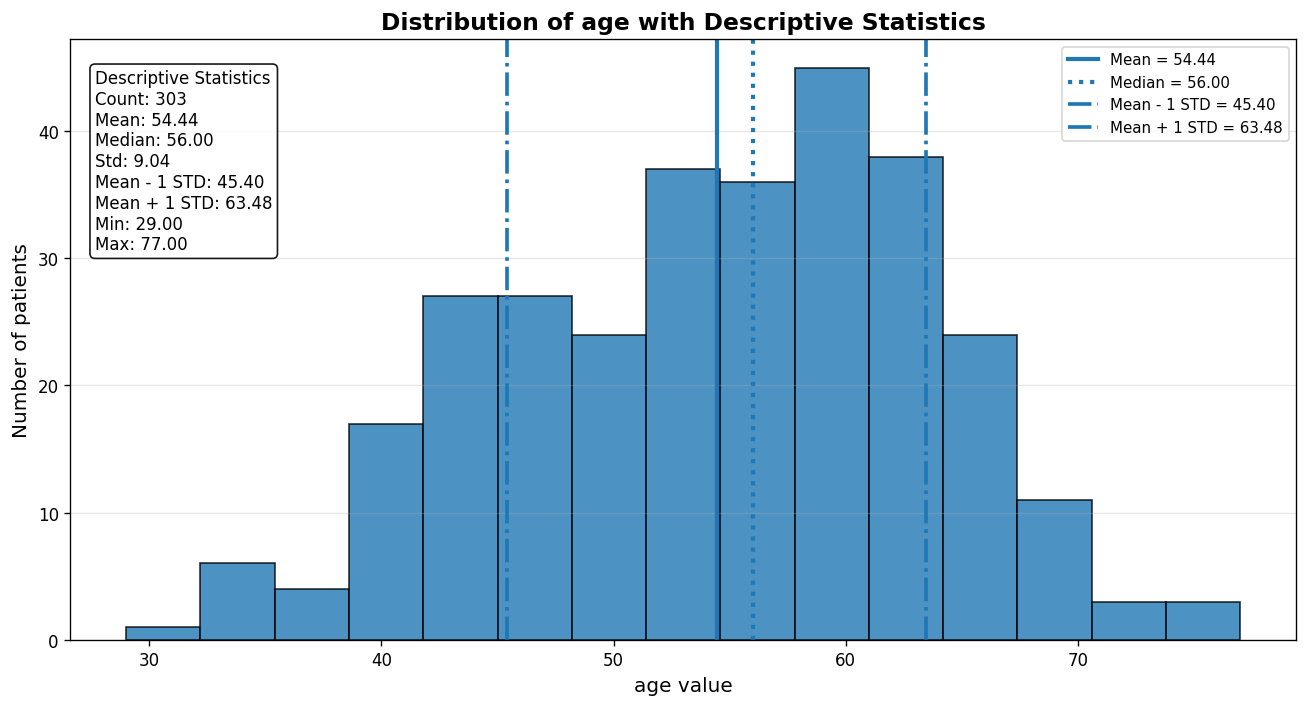

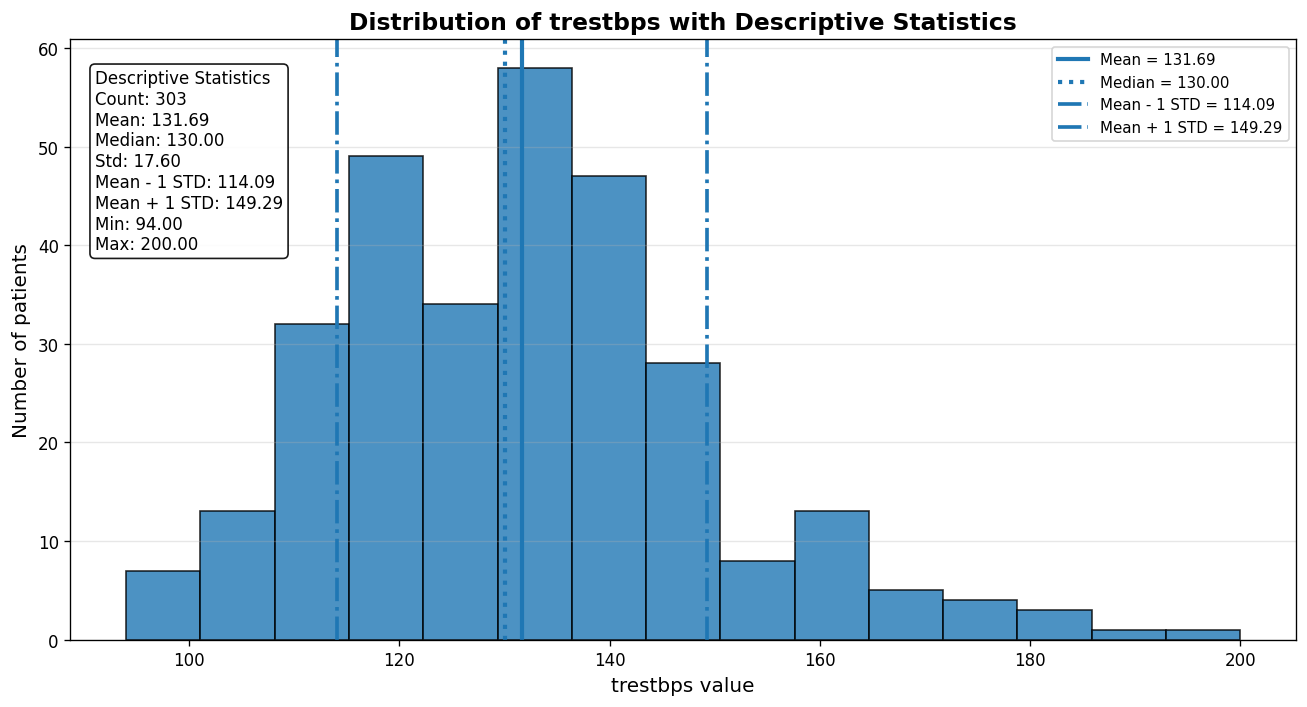

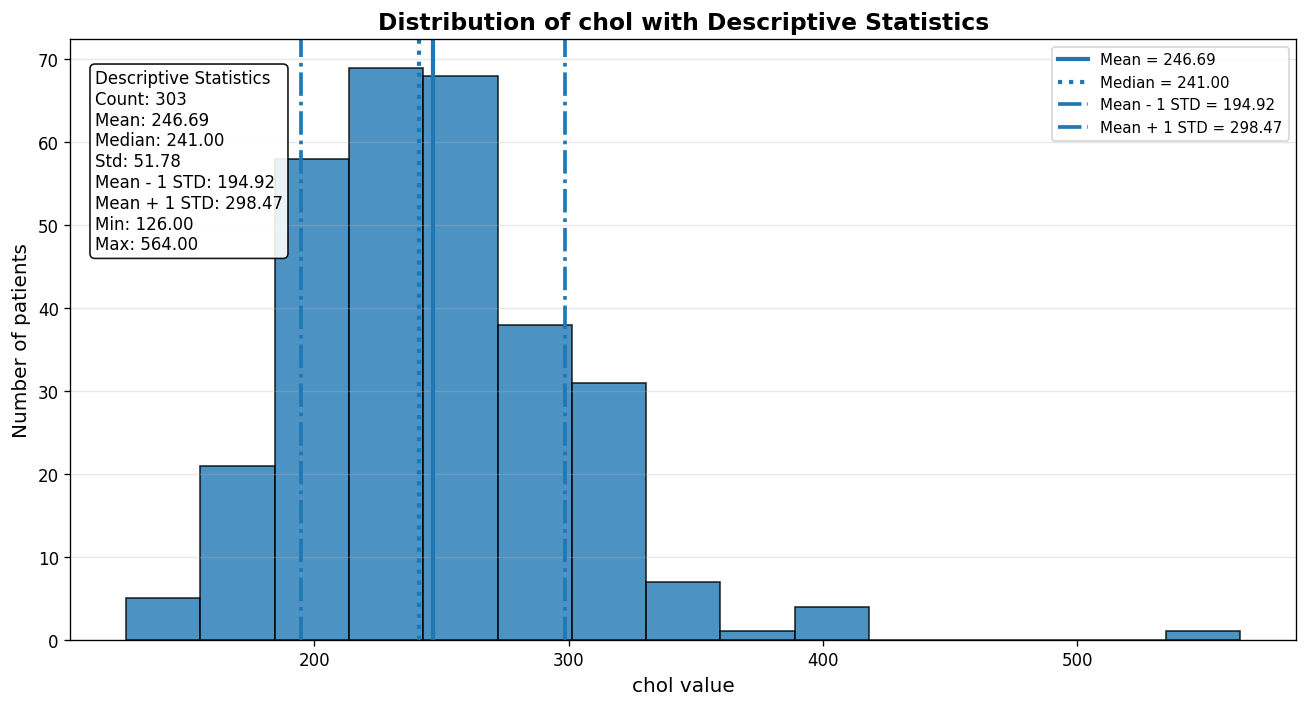

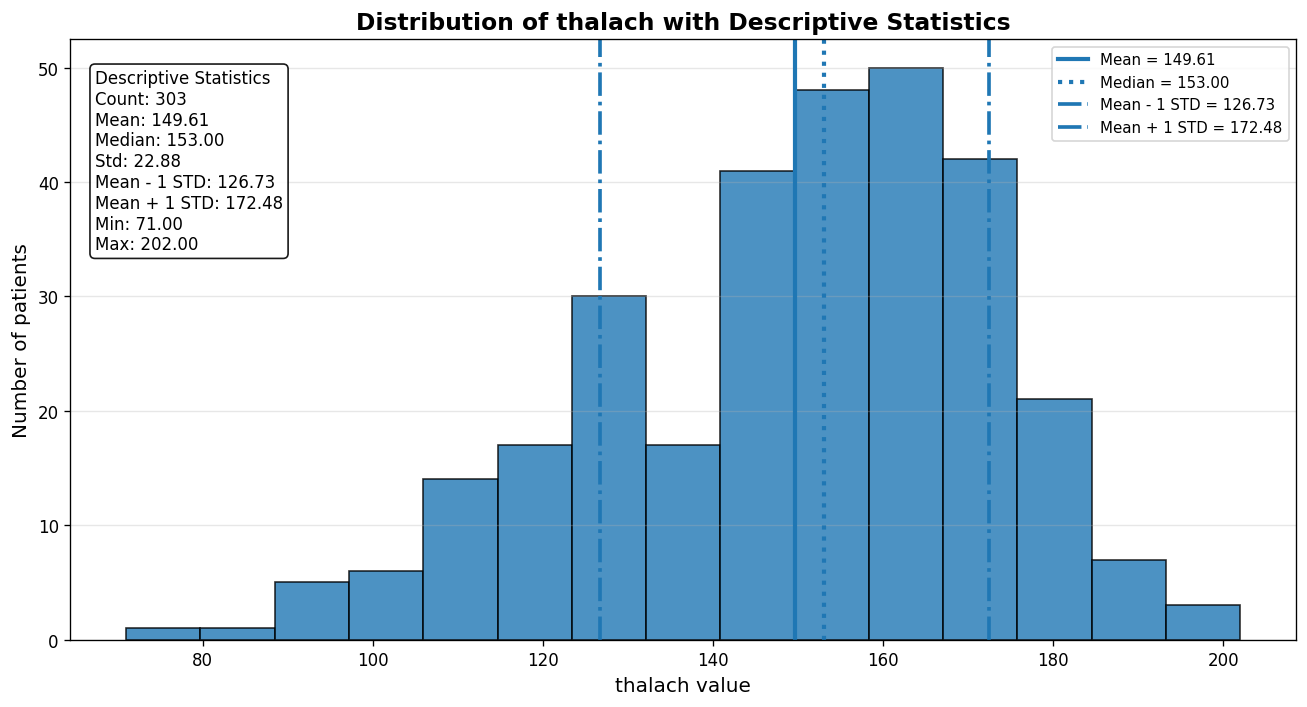

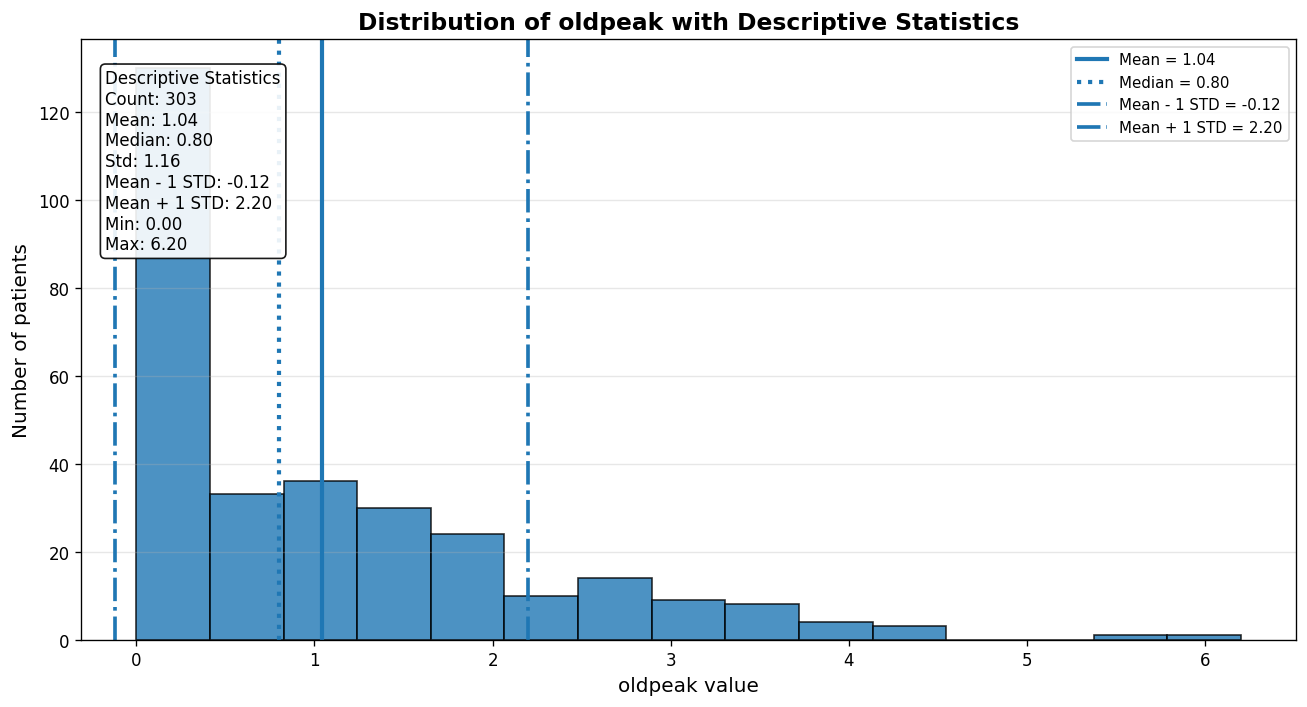

In [13]:
# Cell 13: Distribution Graphs with Descriptive Statistics

# Build the statistics table used inside each graph.
distribution_stats = df[numeric_cols].agg(["count", "mean", "median", "std", "min", "max"]).T

# Create one separate histogram for each numeric feature.
for col in numeric_cols:
    # Calculate descriptive statistics for the current feature.
    count_value = distribution_stats.loc[col, "count"]
    mean_value = distribution_stats.loc[col, "mean"]
    median_value = distribution_stats.loc[col, "median"]
    std_value = distribution_stats.loc[col, "std"]
    min_value = distribution_stats.loc[col, "min"]
    max_value = distribution_stats.loc[col, "max"]

    # Calculate the standard-deviation range around the mean.
    mean_minus_std = mean_value - std_value
    mean_plus_std = mean_value + std_value

    # Create the histogram.
    plt.figure(figsize=(11, 6))
    plt.hist(df[col], bins=15, edgecolor="black", alpha=0.8)

    # Show mean, median, and mean +/- standard deviation as reference lines.
    # Mean is solid, median is dotted, and mean +/- STD uses dash-dot lines.
    plt.axvline(mean_value, linestyle="-", linewidth=2.5, label=f"Mean = {mean_value:.2f}")
    plt.axvline(median_value, linestyle=":", linewidth=2.5, label=f"Median = {median_value:.2f}")
    plt.axvline(mean_minus_std, linestyle="-.", linewidth=2.2, label=f"Mean - 1 STD = {mean_minus_std:.2f}")
    plt.axvline(mean_plus_std, linestyle="-.", linewidth=2.2, label=f"Mean + 1 STD = {mean_plus_std:.2f}")

    # Add the descriptive-statistics box inside the left side of the graph.
    descriptive_text = (
        "Descriptive Statistics\n"
        f"Count: {count_value:.0f}\n"
        f"Mean: {mean_value:.2f}\n"
        f"Median: {median_value:.2f}\n"
        f"Std: {std_value:.2f}\n"
        f"Mean - 1 STD: {mean_minus_std:.2f}\n"
        f"Mean + 1 STD: {mean_plus_std:.2f}\n"
        f"Min: {min_value:.2f}\n"
        f"Max: {max_value:.2f}"
    )

    plt.text(
        0.02, 0.95, descriptive_text,
        transform=plt.gca().transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.90)
    )

    # Put the line labels on the right side of the graph.
    plt.legend(loc="upper right", fontsize=9, frameon=True)

    # Add titles and axis labels.
    plt.title(f"Distribution of {col} with Descriptive Statistics", fontsize=14, fontweight="bold")
    plt.xlabel(f"{col} value", fontsize=12)
    plt.ylabel("Number of patients", fontsize=12)

    # Add gridlines for readability.
    plt.grid(axis="y", alpha=0.3)

    # Prevent overlap and show the graph.
    plt.tight_layout()
    plt.show()


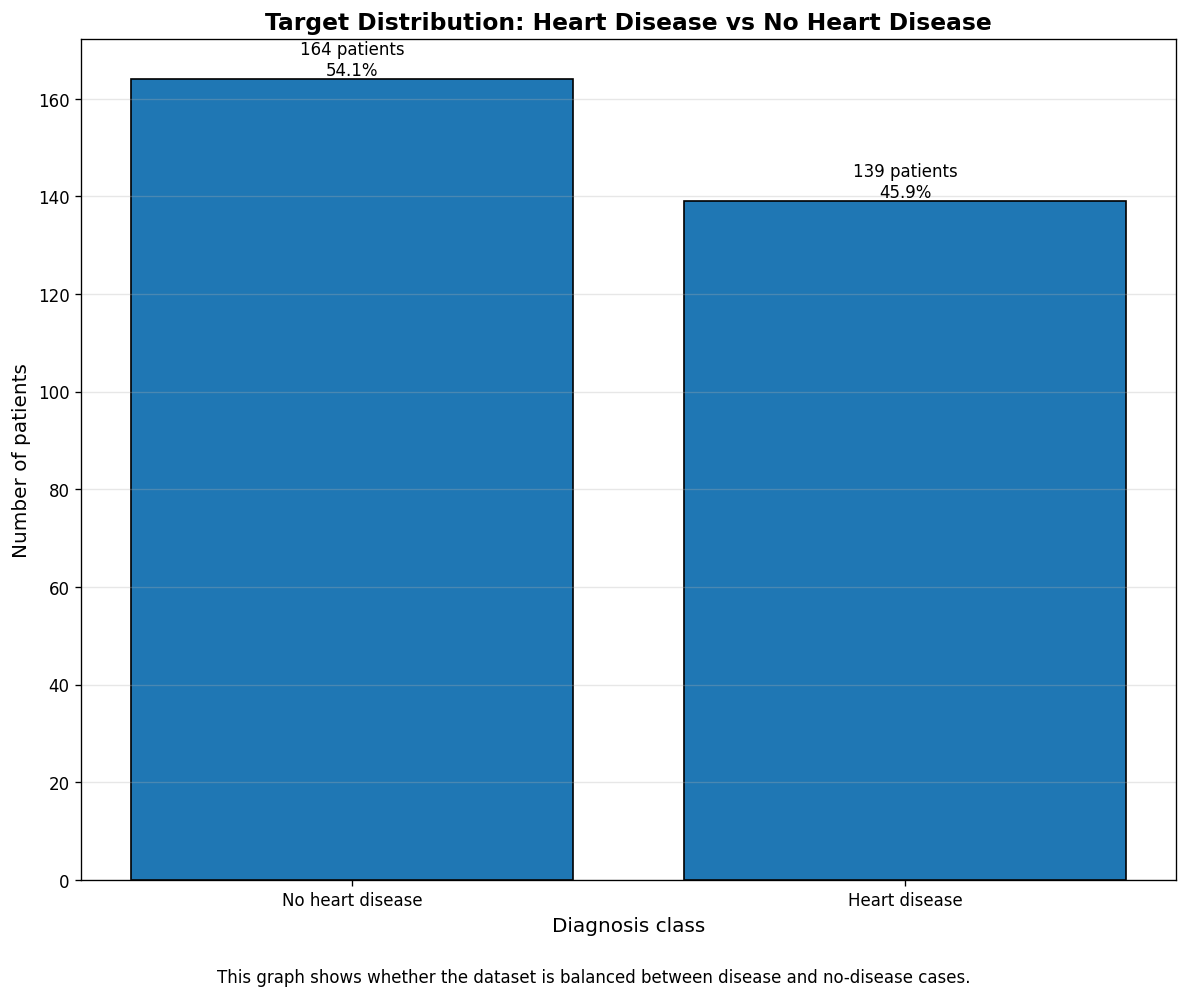

In [14]:
# Cell 14: Target Distribution Graph

# Count the number of patients in each target class.
target_counts = df["target"].value_counts().sort_index()

# Convert counts to percentages for easier interpretation of class balance.
target_percentages = target_counts / target_counts.sum() * 100

# Create labels for the target classes.
target_labels = ["No heart disease", "Heart disease"]

# Create the bar chart.
plt.figure(figsize=(10, 8))
bars = plt.bar(target_labels, target_counts.values, edgecolor="black")

# Add count and percentage labels above each bar.
for bar, count, pct in zip(bars, target_counts.values, target_percentages.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{count} patients\n{pct:.1f}%", ha="center", va="bottom")

# Add title and  x axis and y axis labels.
plt.title("Target Distribution: Heart Disease vs No Heart Disease", fontsize=14, fontweight="bold")
plt.xlabel("Diagnosis class", fontsize=12)
plt.ylabel("Number of patients", fontsize=12)

# Add gridlines to make counts easier to compare.
plt.grid(axis="y", alpha=0.3)

# Add interpretation note.
plt.figtext(0.5, -0.03, "This graph shows whether the dataset is balanced between disease and no-disease cases.", ha="center", fontsize=10)

# Adjust spacing and show the plot.
plt.tight_layout()
plt.show()


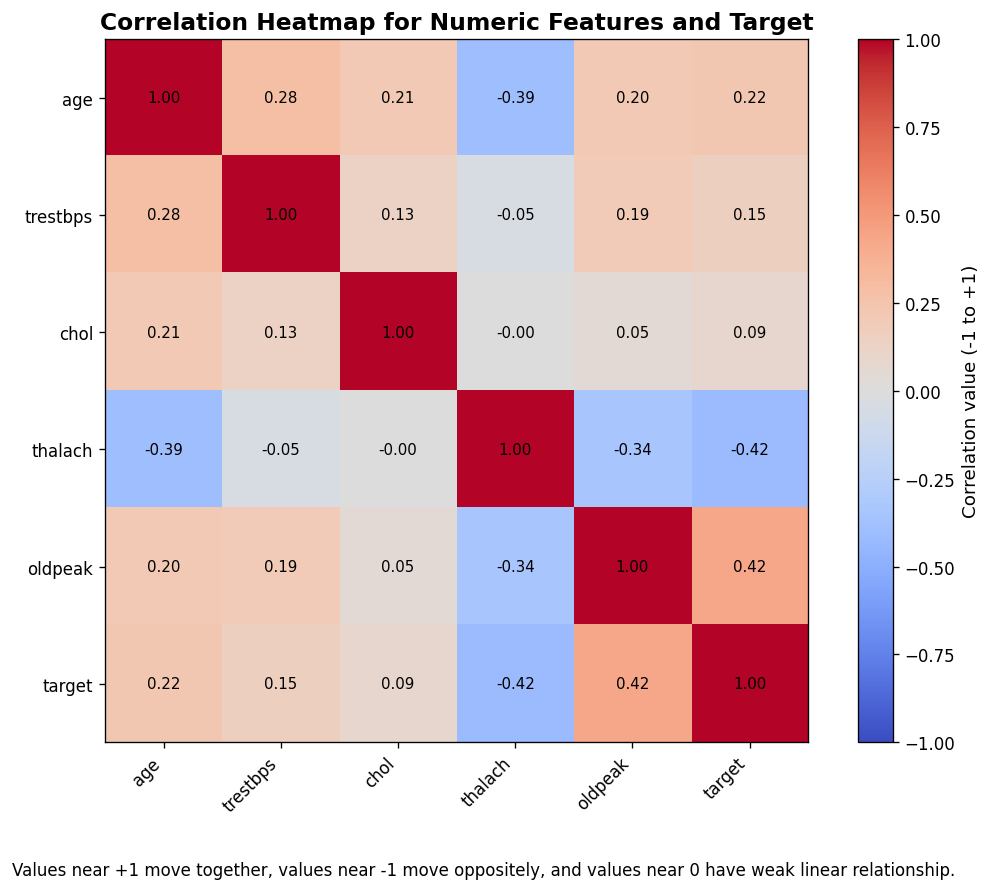

In [15]:
# Cell 15: Correlation Heatmap

# Calculate correlations between numeric features and the binary target.
corr = df[numeric_cols + ["target"]].corr()

# Create the heatmap figure.
plt.figure(figsize=(9, 7))

# Draw the correlation matrix as an image.
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Add a color bar to explain correlation strength and direction.
plt.colorbar(label="Correlation value (-1 to +1)")

# Put feature names on both x and y axes.
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

# Write the exact correlation value inside every cell.
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

# Add a title and an explanation.
plt.title("Correlation Heatmap for Numeric Features and Target", fontsize=14, fontweight="bold")
plt.figtext(0.5, -0.05, "Values near +1 move together, values near -1 move oppositely, and values near 0 have weak linear relationship.", ha="center", fontsize=10)

# Adjust layout and display the heatmap.
plt.tight_layout()
plt.show()


In [16]:
# Cell 16: Feature and Target Selection

# Drop 'num' because it is the original multi-class diagnosis and would duplicate target information.
# Drop 'target' from X because target is what the model must predict, not an input feature.
X = df.drop(columns=["num", "target"])

# Store the binary target column separately as y.
y = df["target"]

# Print the feature names used by the model.
print("Model input features:")
print(X.columns.tolist())

# Print the target name and shape information.
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Model input features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Feature matrix shape: (303, 13)
Target vector shape: (303,)


In [17]:
# Cell 17: Train, Validation, and Test Split
# Ratio: 70% Train, 15% Validation, 15% Test

# Split into Training (70%) and Temp (30%)
# The temporary set will later be split into validation and test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,       # 30% goes to temp (val + test)
    random_state=42,      # Ensures reproducibility (same split every run)
    stratify=y            # Keeps class distribution balanced
)

# Split Temp (30%) into Validation and Test
# 30% split into 15% + 15%

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,       # Half of 30% is 15%
    random_state=42,
    stratify=y_temp
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Testing set size:", X_test.shape)

print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nClass balance in validation set:")
print(y_val.value_counts(normalize=True).sort_index())

print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).sort_index())


Training set size: (212, 13)
Validation set size: (45, 13)
Testing set size: (46, 13)

Class balance in training set:
target
0    0.542453
1    0.457547
Name: proportion, dtype: float64

Class balance in validation set:
target
0    0.533333
1    0.466667
Name: proportion, dtype: float64

Class balance in test set:
target
0    0.543478
1    0.456522
Name: proportion, dtype: float64


In [18]:
# Cell 18: Prepare Predefined Validation Split for GridSearchCV
# GridSearchCV normally performs cross-validation automatically.
# Here, a fixed validation set is used so that hyperparameters are selected using the validation data only.

# Combine training and validation features because GridSearchCV expects one input matrix.
X_trainval = pd.concat([X_train, X_val], axis=0)

# Combine training and validation labels in the same row order.
y_trainval = pd.concat([y_train, y_val], axis=0)

# In PredefinedSplit, -1 means training rows and 0 means validation rows.
test_fold = [-1] * len(X_train) + [0] * len(X_val)

# Create the split object that forces GridSearchCV to use this validation set.
ps = PredefinedSplit(test_fold=test_fold)

# Confirm the combined data size.
print("Combined train + validation shape:", X_trainval.shape)
print("Number of training rows marked as -1:", test_fold.count(-1))
print("Number of validation rows marked as 0:", test_fold.count(0))


Combined train + validation shape: (257, 13)
Number of training rows marked as -1: 212
Number of validation rows marked as 0: 45


In [19]:
# Cell 19: Train Random Forest with GridSearchCV

# Create the Random Forest model.
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter values that GridSearchCV will test.
param_grid = {
    "n_estimators": [100, 200, 300],       # Number of decision trees in the forest.
    "max_depth": [None, 5, 10, 20],        # Maximum depth of each tree.
    "min_samples_split": [2, 5, 10],       # Minimum samples needed to split an internal node.
    "min_samples_leaf": [1, 2, 4],         # Minimum samples required in each leaf node.
    "max_features": ["sqrt", "log2"]       # Number of features considered at each split.
}

# GridSearchCV tests each hyperparameter combination using the predefined validation split.
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="recall",
    cv=ps,
    n_jobs=-1,
    verbose=1
)

# Train and tune the Random Forest model on the training + validation data.
grid_search.fit(X_trainval, y_trainval)

# Store the best model selected by validation recall.
best_rf = grid_search.best_estimator_

# Print the best settings and validation recall score.
print("Best hyperparameters selected by GridSearchCV:")
print(grid_search.best_params_)

print("\nBest validation recall:")
print(grid_search.best_score_)


Fitting 1 folds for each of 216 candidates, totalling 216 fits
Best hyperparameters selected by GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best validation recall:
0.8095238095238095


In [20]:
# Cell 20: Evaluate Final Model on the Test Set

# Predict class labels for the unseen test set.
y_pred = best_rf.predict(X_test)

# Predict probabilities for the positive class: heart disease.
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Calculate standard classification metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_value = roc_auc_score(y_test, y_prob)

# Store metrics in a table for clean display.
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc_value]
})

# Display rounded metric values.
print("Final test-set performance:")
display(metrics_df.round(3))

# Print a detailed class-by-class report.
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))


Final test-set performance:


,Metric,Value
0,Accuracy,0.826
1,Precision,0.783
2,Recall,0.857
3,F1-score,0.818
4,ROC-AUC,0.903


Classification report:
              precision    recall  f1-score   support

  No disease       0.87      0.80      0.83        25
     Disease       0.78      0.86      0.82        21

    accuracy                           0.83        46
   macro avg       0.83      0.83      0.83        46
weighted avg       0.83      0.83      0.83        46



In [21]:
# Cell 21: Install and Import SHAP

# Install SHAP.
!pip install shap

# Import SHAP for RF model explainability.
import shap


In [22]:
# Cell 22: Prepare SHAP Explanations

# Create a SHAP explainer using the trained Random Forest and training data.
explainer = shap.Explainer(best_rf, X_train)

# Calculate SHAP values for the test set.
shap_exp = explainer(X_test)

# Print shapes to verify the explanation object matches the test data.
print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_exp.values.shape)

if len(shap_exp.values.shape) == 3:
    shap_exp_plot = shap_exp[:, :, 1]
    print("Class 1 SHAP values selected because this study explains disease prediction.")
else:
    shap_exp_plot = shap_exp
    print("SHAP values are already two-dimensional, so no class selection was needed.")

# Confirm that the SHAP object is ready for plotting.
print("SHAP explanation prepared for the positive class: heart disease.")


X_test shape: (46, 13)
SHAP values shape: (46, 13, 2)
Class 1 SHAP values selected because this study explains disease prediction.
SHAP explanation prepared for the positive class: heart disease.


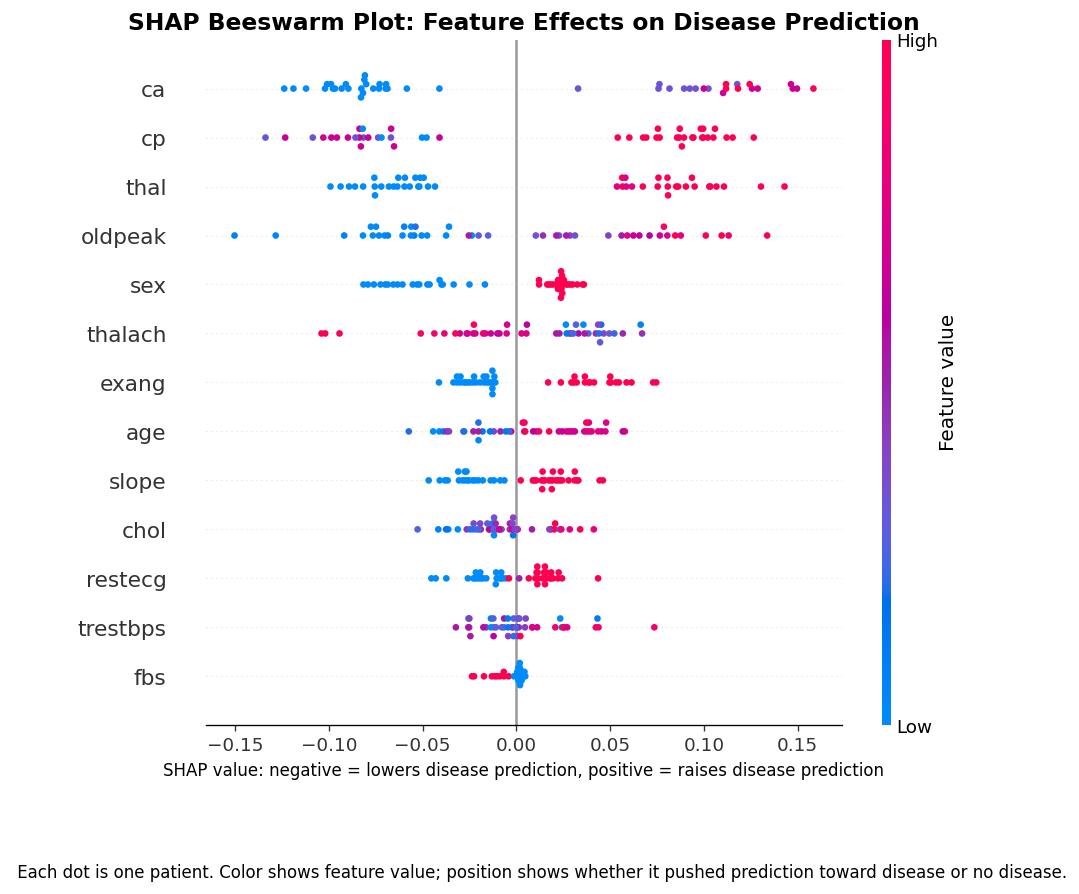

In [23]:
# Cell 23: SHAP Beeswarm Plot

# Create a beeswarm plot showing importance and direction of feature effects.
shap.plots.beeswarm(shap_exp_plot, max_display=13, show=False)

# Add a title and x-axis explanation.
plt.title("SHAP Beeswarm Plot: Feature Effects on Disease Prediction", fontsize=14, fontweight="bold")
plt.xlabel("SHAP value: negative = lowers disease prediction, positive = raises disease prediction", fontsize=10)

# Add an interpretation note.
plt.figtext(0.5, -0.10, " Each dot is one patient. Color shows feature value; position shows whether it pushed prediction toward disease or no disease.", ha="center", fontsize=10)

# Adjust spacing and show the plot.
plt.tight_layout()
plt.show()


In [24]:
# Cell 24: Install and Import LIME

# Install LIME.
!pip install lime

# Import LimeTabularExplainer for local explanations of tabular data models.
from lime.lime_tabular import LimeTabularExplainer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7d0606bc478a35f61339026f6aadb00a91c8867bbb3c42fe9aa8ff828a517ad8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Selected patient input values used for both SHAP and LIME explanations:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
67,54.0,1.0,3.0,150.0,232.0,0.0,2.0,165.0,0.0,1.6,1.0,0.0,7.0


Random Forest predicted class: 0
Predicted probability of no heart disease: 0.540
Predicted probability of heart disease: 0.460
RF SHAP feature contributions for this patient, class = heart disease:


,Feature,Contribution,Absolute contribution
12,thal,0.1304,0.1304
2,cp,-0.0829,0.0829
11,ca,-0.0808,0.0808
7,thalach,-0.0384,0.0384
3,trestbps,0.0271,0.0271
9,oldpeak,0.0266,0.0266
10,slope,-0.0261,0.0261
1,sex,0.0252,0.0252
0,age,-0.0203,0.0203
6,restecg,0.0183,0.0183


RF LIME feature contributions for this patient, class = heart disease:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Feature condition,Contribution,Absolute contribution
0,ca <= 0.00,-0.2264,0.2264
1,cp <= 3.00,-0.1631,0.1631
2,3.00 < thal <= 7.00,0.1511,0.1511
3,0.00 < sex <= 1.00,0.0734,0.0734
4,exang <= 0.00,-0.0591,0.0591
5,slope <= 1.00,-0.0453,0.0453
6,0.00 < restecg <= 2.00,0.0406,0.0406
7,48.00 < age <= 55.00,-0.0360,0.0360
8,trestbps > 140.00,0.0295,0.0295
9,0.80 < oldpeak <= 1.60,0.0280,0.0280


Aligned local explanation rows used in the side-by-side plot:


,Feature,RF SHAP contribution,RF LIME contribution,RF LIME condition
0,restecg,0.0183,0.0406,0.00 < restecg <= 2.00
1,age,-0.0203,-0.0360,48.00 < age <= 55.00
2,sex,0.0252,0.0734,0.00 < sex <= 1.00
3,slope,-0.0261,-0.0453,slope <= 1.00
4,oldpeak,0.0266,0.0280,0.80 < oldpeak <= 1.60
5,trestbps,0.0271,0.0295,trestbps > 140.00
6,thalach,-0.0384,-0.0186,153.00 < thalach <= 165.00
7,ca,-0.0808,-0.2264,ca <= 0.00
8,cp,-0.0829,-0.1631,cp <= 3.00
9,thal,0.1304,0.1511,3.00 < thal <= 7.00


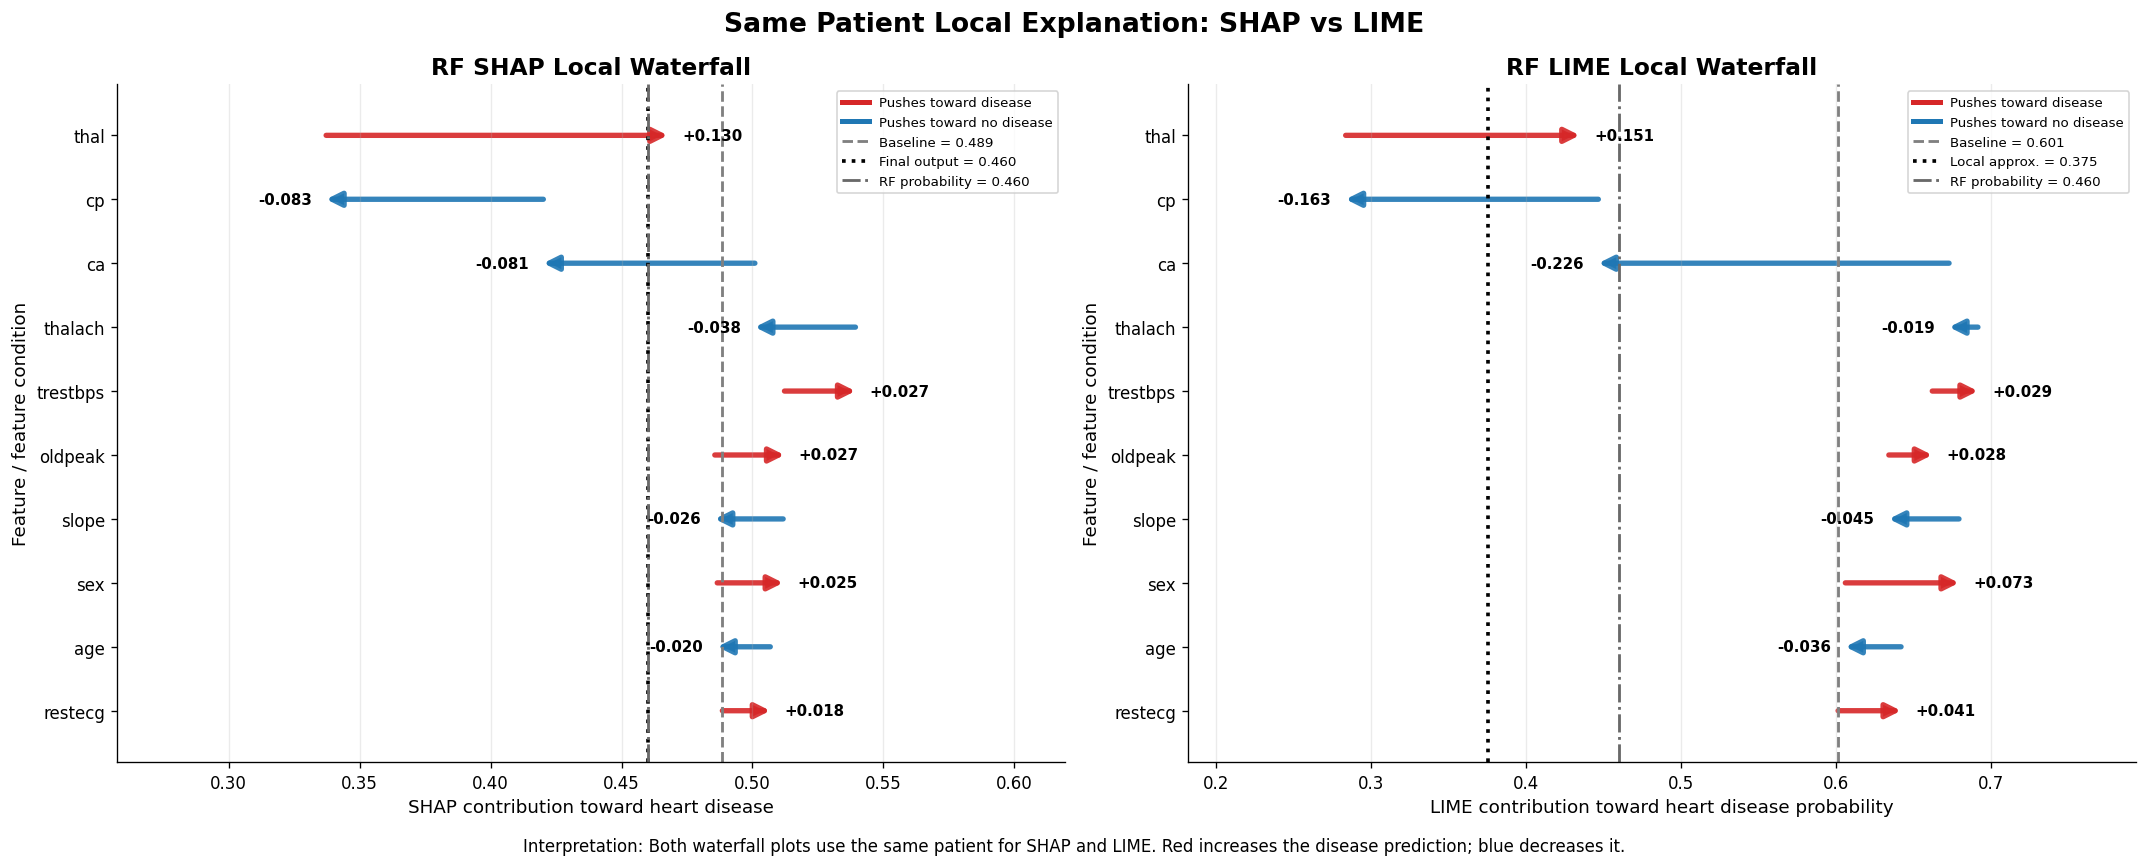

In [25]:
# Cell 25: SHAP and LIME Local Waterfall Explanations

# Import FancyArrowPatch to draw arrow-style waterfall steps.
from matplotlib.patches import FancyArrowPatch
import re

# Select one patient from the test set for detailed explanation.
patient_index = 0

# Display the selected patient's input feature values once, because both SHAP and LIME explain the same patient.
print("Selected patient input values used for both SHAP and LIME explanations:")
display(X_test.iloc[[patient_index]])

# Print the Random Forest prediction for this patient.
rf_patient_prediction = best_rf.predict(X_test.iloc[[patient_index]])[0]
rf_patient_probability = best_rf.predict_proba(X_test.iloc[[patient_index]])[0]
print("Random Forest predicted class:", rf_patient_prediction)
print(f"Predicted probability of no heart disease: {rf_patient_probability[0]:.3f}")
print(f"Predicted probability of heart disease: {rf_patient_probability[1]:.3f}")

def plot_local_waterfall_arrow(
    contributions_df,
    base_value,
    final_value,
    feature_label_col,
    contribution_col,
    title,
    xlabel,
    baseline_label,
    final_label,
    ax=None,
    top_n=10,
    actual_prediction=None,
    actual_prediction_label=None
):
    """
    Draw a local explanation waterfall.
    Positive contributions are red arrows pointing right.
    Negative contributions are blue arrows pointing left.
    The same function is used for SHAP and LIME so the two plots can be compared directly.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    plot_df = contributions_df.copy()
    plot_df["Absolute contribution"] = plot_df[contribution_col].abs()

    if top_n is not None:
        plot_df = plot_df.sort_values("Absolute contribution", ascending=False).head(top_n)
        plot_df = plot_df.sort_values("Absolute contribution", ascending=True).reset_index(drop=True)
    else:
        plot_df = plot_df.reset_index(drop=True)

    y_positions = np.arange(len(plot_df))
    running_value = float(base_value)

    # Reference lines are identical for both SHAP and LIME.
    ax.axvline(base_value, linestyle="--", linewidth=1.7, color="gray", label=baseline_label)
    ax.axvline(final_value, linestyle=":", linewidth=2.2, color="black", label=final_label)

    if actual_prediction is not None:
        ax.axvline(
            actual_prediction,
            linestyle="-.",
            linewidth=1.7,
            color="dimgray",
            label=actual_prediction_label
        )

    running_values = [base_value, final_value]
    running_value = float(base_value)

    # Draw each contribution as an arrow step.
    for y_pos, (_, row) in zip(y_positions, plot_df.iterrows()):
        contribution = float(row[contribution_col])
        next_value = running_value + contribution
        arrow_color = GRAPH_COLORS["positive"] if contribution >= 0 else GRAPH_COLORS["negative"]

        arrow = FancyArrowPatch(
            (running_value, y_pos),
            (next_value, y_pos),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=3.2,
            color=arrow_color,
            shrinkA=0,
            shrinkB=0,
            alpha=0.90,
            clip_on=False
        )
        ax.add_patch(arrow)

        running_values.extend([running_value, next_value])
        running_value = next_value

    # Axis limits must include all reference lines and running values.
    all_values = running_values.copy()
    if actual_prediction is not None:
        all_values.append(actual_prediction)
    value_range = max(all_values) - min(all_values)
    padding = max(value_range * 0.25, 0.08)
    ax.set_xlim(min(all_values) - padding, max(all_values) + padding)

    # Add contribution labels after x-limits are known, so labels are consistently spaced.
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    label_offset = 0.015 * x_range
    running_value = float(base_value)
    for y_pos, (_, row) in zip(y_positions, plot_df.iterrows()):
        contribution = float(row[contribution_col])
        next_value = running_value + contribution
        label_x = next_value + label_offset if contribution >= 0 else next_value - label_offset
        label_align = "left" if contribution >= 0 else "right"
        ax.text(
            label_x,
            y_pos,
            f"{contribution:+.3f}",
            va="center",
            ha=label_align,
            fontsize=9,
            fontweight="bold",
            clip_on=False
        )
        running_value = next_value

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_df[feature_label_col])

    # Add vertical padding so the top and bottom arrow heads are fully visible.
    if len(y_positions) > 0:
        ax.set_ylim(y_positions[0] - 0.8, y_positions[-1] + 0.8)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Feature / feature condition")
    tidy_axis(ax, grid_axis="x")

    legend_items = [
        Line2D([0], [0], color=GRAPH_COLORS["positive"], lw=3, label="Pushes toward disease"),
        Line2D([0], [0], color=GRAPH_COLORS["negative"], lw=3, label="Pushes toward no disease"),
        Line2D([0], [0], color="gray", lw=1.7, linestyle="--", label=baseline_label),
        Line2D([0], [0], color="black", lw=2.2, linestyle=":", label=final_label),
    ]
    if actual_prediction is not None:
        legend_items.append(Line2D([0], [0], color="dimgray", lw=1.7, linestyle="-.", label=actual_prediction_label))
    ax.legend(handles=legend_items, loc="best", fontsize=8)

    return ax

# SHAP explanation table
shap_patient_exp = shap_exp_plot[patient_index]
shap_table = pd.DataFrame({
    "Feature": list(X_test.columns),
    "Contribution": shap_patient_exp.values
})
shap_base_value = float(np.ravel(shap_patient_exp.base_values)[0])
shap_final_value = shap_base_value + shap_table["Contribution"].sum()

print("RF SHAP feature contributions for this patient, class = heart disease:")
display(
    shap_table
    .assign(**{"Absolute contribution": shap_table["Contribution"].abs()})
    .sort_values("Absolute contribution", ascending=False)
    .round(4)
)

# LIME explanation table

class_names = ["No heart disease", "Heart disease"]

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=list(X_train.columns),
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_patient = X_test.iloc[patient_index]
lime_exp = lime_explainer.explain_instance(
    data_row=lime_patient.values,
    predict_fn=best_rf.predict_proba,
    num_features=len(X_train.columns)
)

lime_table = pd.DataFrame(lime_exp.as_list(label=1), columns=["Feature condition", "Contribution"])
lime_table["Absolute contribution"] = lime_table["Contribution"].abs()
lime_base_value = float(lime_exp.intercept[1])
lime_final_local_prediction = lime_base_value + lime_table["Contribution"].sum()

print("RF LIME feature contributions for this patient, class = heart disease:")
display(lime_table.sort_values("Absolute contribution", ascending=False).round(4))

# Build aligned SHAP and LIME tables so both waterfall plots use the same features in the same order.
# The order is defined by the strongest SHAP contributors and LIME contributions are matched back to the original feature name.
def extract_lime_base_feature(feature_condition, feature_names):
    """Map a LIME condition such as '3.00 < thal <= 7.00' back to 'thal'."""
    condition_text = str(feature_condition)
    matches = [
        feature for feature in feature_names
        if re.search(rf"(?<![A-Za-z0-9_]){re.escape(feature)}(?![A-Za-z0-9_])", condition_text)
    ]
    if matches:
        # Prefer the longest match in case one feature name is contained in another.
        return max(matches, key=len)
    return condition_text

aligned_feature_order = (
    shap_table
    .assign(**{"Absolute contribution": shap_table["Contribution"].abs()})
    .sort_values("Absolute contribution", ascending=False)
    .head(10)["Feature"]
    .tolist()
)
# Matplotlib places the last y position at the top, so reverse the list to keep the strongest feature visually at the top while preserving row alignment.
aligned_feature_order = list(reversed(aligned_feature_order))

shap_table_aligned = (
    shap_table
    .set_index("Feature")
    .loc[aligned_feature_order]
    .reset_index()
)

lime_table_aligned = lime_table.copy()
lime_table_aligned["Feature"] = lime_table_aligned["Feature condition"].apply(
    lambda condition: extract_lime_base_feature(condition, list(X_train.columns))
)

# Aggregate defensively in case LIME produces more than one condition for a feature.
lime_table_aligned = (
    lime_table_aligned
    .groupby("Feature", as_index=False)
    .agg({
        "Contribution": "sum",
        "Feature condition": lambda values: " + ".join(map(str, values))
    })
    .set_index("Feature")
    .reindex(aligned_feature_order)
    .reset_index()
)

lime_table_aligned["Contribution"] = lime_table_aligned["Contribution"].fillna(0.0)
lime_table_aligned["Feature condition"] = lime_table_aligned["Feature condition"].fillna(
    lime_table_aligned["Feature"] + " not selected by LIME"
)
lime_table_aligned["Absolute contribution"] = lime_table_aligned["Contribution"].abs()

print("Aligned local explanation rows used in the side-by-side plot:")
display(pd.DataFrame({
    "Feature": aligned_feature_order,
    "RF SHAP contribution": shap_table_aligned["Contribution"].values,
    "RF LIME contribution": lime_table_aligned["Contribution"].values,
    "RF LIME condition": lime_table_aligned["Feature condition"].values
}).round(4))

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)

plot_local_waterfall_arrow(
    contributions_df=shap_table_aligned,
    base_value=shap_base_value,
    final_value=shap_final_value,
    feature_label_col="Feature",
    contribution_col="Contribution",
    title="RF SHAP Local Waterfall",
    xlabel="SHAP contribution toward heart disease",
    baseline_label=f"Baseline = {shap_base_value:.3f}",
    final_label=f"Final output = {shap_final_value:.3f}",
    actual_prediction=rf_patient_probability[1],
    actual_prediction_label=f"RF probability = {rf_patient_probability[1]:.3f}",
    ax=axes[0],
    top_n=None
)

plot_local_waterfall_arrow(
    contributions_df=lime_table_aligned,
    base_value=lime_base_value,
    final_value=lime_final_local_prediction,
    feature_label_col="Feature",
    contribution_col="Contribution",
    title="RF LIME Local Waterfall",
    xlabel="LIME contribution toward heart disease probability",
    baseline_label=f"Baseline = {lime_base_value:.3f}",
    final_label=f"Local approx. = {lime_final_local_prediction:.3f}",
    actual_prediction=rf_patient_probability[1],
    actual_prediction_label=f"RF probability = {rf_patient_probability[1]:.3f}",
    ax=axes[1],
    top_n=None
)

fig.suptitle("Same Patient Local Explanation: SHAP vs LIME", fontsize=16, fontweight="bold")
add_note(
    fig,
    "Interpretation: Both waterfall plots use the same patient for SHAP and LIME. Red increases the disease prediction; blue decreases it.",
    y=-0.02
)
plt.tight_layout()
plt.show()


In [26]:
# Cell 26: Train Logistic Regression with Normalization and GridSearchCV

# Import LogisticRegression to train a linear classification model.
from sklearn.linear_model import LogisticRegression

# Import StandardScaler to normalize numeric feature values before Logistic Regression.
from sklearn.preprocessing import StandardScaler

# Import Pipeline so scaling and model training happen together safely.
from sklearn.pipeline import Pipeline

# Logistic Regression is sensitive to feature scale.
# Example: cholesterol values are much larger than binary variables such as sex or exang.
# If normalization is not used, larger-scale features can unfairly influence the model.
# StandardScaler converts each feature to a similar scale using mean and standard deviation.

# Create a pipeline with two steps.
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),                         # Step 1: normalize feature values.
    ("logistic_regression", LogisticRegression(           # Step 2: train Logistic Regression.
        random_state=42,                                  # Makes results reproducible.
        max_iter=1000                                     # Allows enough iterations
    ))
])

# Define hyperparameter values that GridSearchCV will test for Logistic Regression.
lr_param_grid = {
    "logistic_regression__C": [0.01, 0.1, 1, 10, 100],      # Smaller C means stronger regularization.
    "logistic_regression__penalty": ["l1", "l2"],           # L1 may remove weak features; L2 reduces large coefficients smoothly.
    "logistic_regression__solver": ["liblinear"],           # liblinear supports both L1 and L2 penalties.
    "logistic_regression__class_weight": [None, "balanced"] # balanced helps if classes are not perfectly equal.
}

# Create GridSearchCV for Logistic Regression.
# Recall is used because missing actual heart disease cases is risky in a medical dataset.
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,          # Model pipeline being tuned.
    param_grid=lr_param_grid,       # Hyperparameter combinations to test.
    scoring="recall",              # Selects the model with the best disease-detection recall.
    cv=ps,                          # Uses the same predefined train/validation split as Random Forest.
    n_jobs=-1,                      # Uses all available CPU cores.
    verbose=1                       # Prints progress while tuning.
)

# Fit Logistic Regression using the combined training + validation data.
# The PredefinedSplit object ensures validation rows are only used for model selection.
lr_grid_search.fit(X_trainval, y_trainval)

# Store the best Logistic Regression pipeline selected by validation recall.
best_lr = lr_grid_search.best_estimator_

# Print the best hyperparameter settings.
print("Best Logistic Regression hyperparameters selected by GridSearchCV:")
print(lr_grid_search.best_params_)

# Print the best validation recall score.
print("\nBest Logistic Regression validation recall:")
print(lr_grid_search.best_score_)

# Extract original Logistic Regression coefficients from the pipeline
original_lr_model = best_lr.named_steps["logistic_regression"]

lr_coef_df = pd.DataFrame({
    "Feature": X_trainval.columns,
    "Coefficient": original_lr_model.coef_[0],
    "Absolute coefficient": np.abs(original_lr_model.coef_[0])
}).sort_values("Absolute coefficient", ascending=False)

print("Original Logistic Regression coefficients after normalization:")
display(lr_coef_df.round(4))


Fitting 1 folds for each of 20 candidates, totalling 20 fits
Best Logistic Regression hyperparameters selected by GridSearchCV:
{'logistic_regression__C': 0.01, 'logistic_regression__class_weight': None, 'logistic_regression__penalty': 'l2', 'logistic_regression__solver': 'liblinear'}

Best Logistic Regression validation recall:
0.7142857142857143
Original Logistic Regression coefficients after normalization:


,Feature,Coefficient,Absolute coefficient
11,ca,0.2818,0.2818
12,thal,0.2687,0.2687
2,cp,0.2026,0.2026
8,exang,0.1907,0.1907
9,oldpeak,0.1829,0.1829
7,thalach,-0.1809,0.1809
1,sex,0.1655,0.1655
10,slope,0.1193,0.1193
6,restecg,0.0862,0.0862
0,age,0.0822,0.0822


In [27]:
# Cell 27: Evaluate Final Logistic Regression Model on the Test Set

# Predict class labels for the unseen test set.
lr_pred = best_lr.predict(X_test)

# Predict probabilities for the positive class: heart disease.
lr_prob = best_lr.predict_proba(X_test)[:, 1]

# Calculate Logistic Regression accuracy.
lr_accuracy = accuracy_score(y_test, lr_pred)

# Calculate Logistic Regression precision.
lr_precision = precision_score(y_test, lr_pred)

# Calculate Logistic Regression recall.
lr_recall = recall_score(y_test, lr_pred)

# Calculate Logistic Regression F1-score.
lr_f1 = f1_score(y_test, lr_pred)

# Calculate Logistic Regression ROC-AUC.
lr_roc_auc = roc_auc_score(y_test, lr_prob)

# Store Logistic Regression metrics in a table for clean display.
lr_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression Value": [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc]
})

# Display rounded test-set metric values.
print("Final Logistic Regression test-set performance:")
display(lr_metrics_df.round(3))

# Print a detailed class-by-class performance report.
print("Logistic Regression classification report:")
print(classification_report(y_test, lr_pred, target_names=["No disease", "Disease"]))


Final Logistic Regression test-set performance:


,Metric,Logistic Regression Value
0,Accuracy,0.870
1,Precision,0.826
2,Recall,0.905
3,F1-score,0.864
4,ROC-AUC,0.950


Logistic Regression classification report:
              precision    recall  f1-score   support

  No disease       0.91      0.84      0.88        25
     Disease       0.83      0.90      0.86        21

    accuracy                           0.87        46
   macro avg       0.87      0.87      0.87        46
weighted avg       0.87      0.87      0.87        46



In [28]:
# Cell 28: Logistic Regression Normalization Without Pipeline and PredefinedSplit

# This version does not use Pipeline and PredefinedSplit.
# It manually reproduces the same train/validation model selection logic used by original logistic regression.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import recall_score

# Define the same hyperparameter candidates without pipeline.
lr_v2_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

# Manual validation selection
# For model selection, fit the scaler on X_train only, then evaluate on X_val.
# The scaler is learned from the training rows only, not from validation rows.
lr_v2_selection_scaler = StandardScaler()
X_train_scaled_for_selection = lr_v2_selection_scaler.fit_transform(X_train)
X_val_scaled_for_selection = lr_v2_selection_scaler.transform(X_val)

best_lr_v2_validation_recall = -np.inf
best_lr_v2_params = None

for params in ParameterGrid(lr_v2_param_grid):
    candidate_lr = LogisticRegression(
        random_state=42,
        max_iter=1000,
        **params
    )
    candidate_lr.fit(X_train_scaled_for_selection, y_train)
    candidate_val_pred = candidate_lr.predict(X_val_scaled_for_selection)
    candidate_recall = recall_score(y_val, candidate_val_pred)

    # Use strict greater than so ties keep the first parameter combination,
    # matching GridSearchCV's default tie behavior.
    if candidate_recall > best_lr_v2_validation_recall:
        best_lr_v2_validation_recall = candidate_recall
        best_lr_v2_params = params

# Final manual refit
# After choosing hyperparameters, refit the scaler and model on train + validation like GridSearchCV does for the original logistic regression model.
lr_v2_scaler = StandardScaler()
X_trainval_scaled_v2 = lr_v2_scaler.fit_transform(X_trainval)
X_train_scaled_v2 = lr_v2_scaler.transform(X_train)
X_val_scaled_v2 = lr_v2_scaler.transform(X_val)
X_test_scaled_v2 = lr_v2_scaler.transform(X_test)

# Convert scaled arrays back to DataFrames so feature names remain readable.
X_trainval_scaled_v2 = pd.DataFrame(X_trainval_scaled_v2, columns=X_trainval.columns, index=X_trainval.index)
X_train_scaled_v2 = pd.DataFrame(X_train_scaled_v2, columns=X_train.columns, index=X_train.index)
X_val_scaled_v2 = pd.DataFrame(X_val_scaled_v2, columns=X_val.columns, index=X_val.index)
X_test_scaled_v2 = pd.DataFrame(X_test_scaled_v2, columns=X_test.columns, index=X_test.index)

# Create and fit the final Logistic Regression model without pipeline.
best_lr_v2 = LogisticRegression(
    random_state=42,
    max_iter=1000,
    **best_lr_v2_params
)
best_lr_v2.fit(X_trainval_scaled_v2, y_trainval)

print("Best Logistic Regression V2 hyperparameters selected manually on the validation set:")
print(best_lr_v2_params)

print("\nBest manual validation recall:")
print(best_lr_v2_validation_recall)

print("\nSanity check against original LR hyperparameters from Cell 29:")
original_lr_params_for_check = {
    key.replace("logistic_regression__", ""): value
    for key, value in lr_grid_search.best_params_.items()
}
print(original_lr_params_for_check)
print("Parameters match original LR:", best_lr_v2_params == original_lr_params_for_check)


Best Logistic Regression V2 hyperparameters selected manually on the validation set:
{'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

Best manual validation recall:
0.7142857142857143

Sanity check against original LR hyperparameters from Cell 29:
{'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Parameters match original LR: True


In [29]:
# Cell 29: Evaluate Logistic Regression Version 2 on Validation and Test Sets

# Predict validation labels and probabilities using the LR V2 model.
lr_v2_val_pred = best_lr_v2.predict(X_val_scaled_v2)
lr_v2_val_prob = best_lr_v2.predict_proba(X_val_scaled_v2)[:, 1]

# Predict test labels and probabilities.
lr_v2_test_pred = best_lr_v2.predict(X_test_scaled_v2)
lr_v2_test_prob = best_lr_v2.predict_proba(X_test_scaled_v2)[:, 1]

# Store validation and test metrics.
lr_v2_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Validation": [
        accuracy_score(y_val, lr_v2_val_pred),
        precision_score(y_val, lr_v2_val_pred),
        recall_score(y_val, lr_v2_val_pred),
        f1_score(y_val, lr_v2_val_pred),
        roc_auc_score(y_val, lr_v2_val_prob)
    ],
    "Test": [
        accuracy_score(y_test, lr_v2_test_pred),
        precision_score(y_test, lr_v2_test_pred),
        recall_score(y_test, lr_v2_test_pred),
        f1_score(y_test, lr_v2_test_pred),
        roc_auc_score(y_test, lr_v2_test_prob)
    ]
})

print("Logistic Regression V2 performance using direct normalization:")
display(lr_v2_metrics_df.round(3))

print("Logistic Regression V2 classification report on the test set:")
print(classification_report(y_test, lr_v2_test_pred, target_names=["No disease", "Disease"]))


Logistic Regression V2 performance using direct normalization:


,Metric,Validation,Test
0,Accuracy,0.867,0.870
1,Precision,0.895,0.826
2,Recall,0.810,0.905
3,F1-score,0.850,0.864
4,ROC-AUC,0.931,0.950


Logistic Regression V2 classification report on the test set:
              precision    recall  f1-score   support

  No disease       0.91      0.84      0.88        25
     Disease       0.83      0.90      0.86        21

    accuracy                           0.87        46
   macro avg       0.87      0.87      0.87        46
weighted avg       0.87      0.87      0.87        46



Logistic Regression V2 coefficients after normalization:


,Feature,Coefficient,Absolute coefficient
11,ca,0.2818,0.2818
12,thal,0.2687,0.2687
2,cp,0.2026,0.2026
8,exang,0.1907,0.1907
9,oldpeak,0.1829,0.1829
7,thalach,-0.1809,0.1809
1,sex,0.1655,0.1655
10,slope,0.1193,0.1193
6,restecg,0.0862,0.0862
0,age,0.0822,0.0822


Coefficient difference between original LR vs LR V2


,Feature,Original LR coefficient,LR V2 coefficient,Coefficient difference,Absolute difference
0,ca,0.281808,0.281808,0.0,0.0
1,thal,0.268652,0.268652,0.0,0.0
2,cp,0.202579,0.202579,0.0,0.0
3,exang,0.190716,0.190716,0.0,0.0
4,oldpeak,0.182893,0.182893,0.0,0.0
5,thalach,-0.180933,-0.180933,0.0,0.0
6,sex,0.165490,0.165490,0.0,0.0
7,slope,0.119296,0.119296,0.0,0.0
8,restecg,0.086182,0.086182,0.0,0.0
9,age,0.082188,0.082188,0.0,0.0


Maximum absolute coefficient difference: 0.0


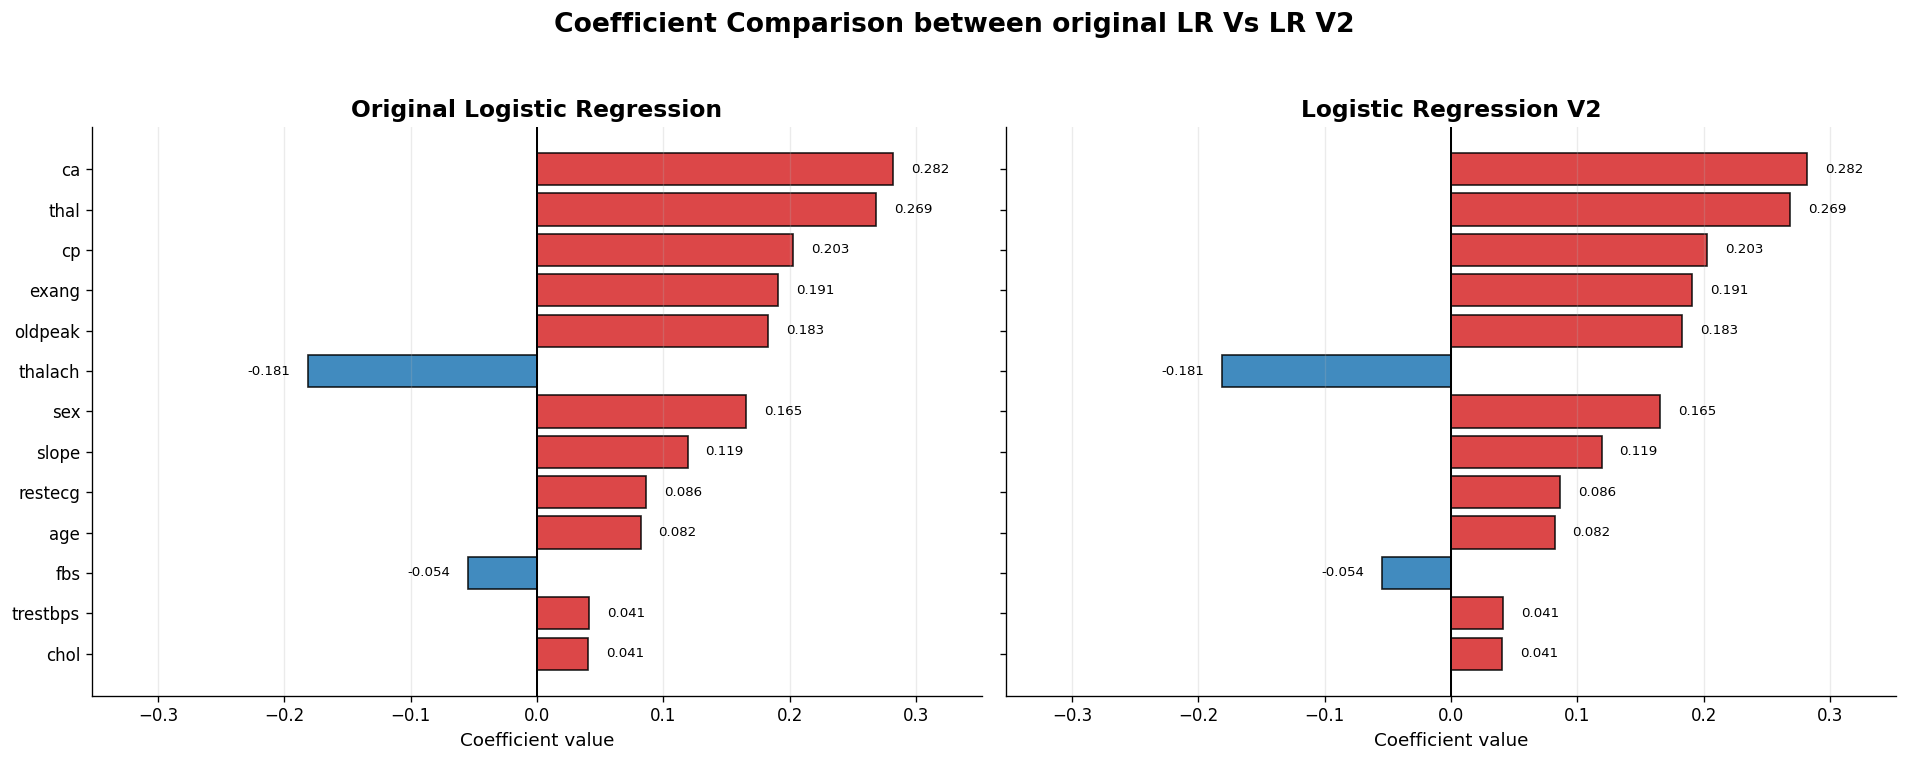

In [30]:
# Cell 30: Side by Side Logistic Regression Coefficient Comparison

# Extract coefficients from Logistic Regression V2.
lr_v2_coefficients = best_lr_v2.coef_[0]

lr_v2_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_v2_coefficients,
    "Absolute coefficient": np.abs(lr_v2_coefficients)
}).sort_values("Absolute coefficient", ascending=False)

print("Logistic Regression V2 coefficients after normalization:")
display(lr_v2_coef_df.round(4))

# Directly quantify coefficient differences.
lr_coef_difference_df = (
    lr_coef_df[["Feature", "Coefficient"]]
    .rename(columns={"Coefficient": "Original LR coefficient"})
    .merge(
        lr_v2_coef_df[["Feature", "Coefficient"]].rename(columns={"Coefficient": "LR V2 coefficient"}),
        on="Feature",
        how="inner"
    )
)
lr_coef_difference_df["Coefficient difference"] = (
    lr_coef_difference_df["LR V2 coefficient"] - lr_coef_difference_df["Original LR coefficient"]
)
lr_coef_difference_df["Absolute difference"] = lr_coef_difference_df["Coefficient difference"].abs()
lr_coef_difference_df = lr_coef_difference_df.sort_values("Absolute difference", ascending=False)

print("Coefficient difference between original LR vs LR V2")
display(lr_coef_difference_df.round(6))
print("Maximum absolute coefficient difference:", round(lr_coef_difference_df["Absolute difference"].max(), 8))

# Use the same feature order for both plots so coefficient direction and size are easier to compare.
shared_feature_order = (
    pd.concat([
        lr_coef_df[["Feature", "Absolute coefficient"]],
        lr_v2_coef_df[["Feature", "Absolute coefficient"]]
    ])
    .groupby("Feature", as_index=False)["Absolute coefficient"]
    .max()
    .sort_values("Absolute coefficient", ascending=True)["Feature"]
    .tolist()
)

lr_coef_plot_df = lr_coef_df.set_index("Feature").loc[shared_feature_order].reset_index()
lr_v2_coef_plot_df = lr_v2_coef_df.set_index("Feature").loc[shared_feature_order].reset_index()

# Use the same x-axis scale for a fair visual comparison.
max_abs_coef = max(
    lr_coef_plot_df["Coefficient"].abs().max(),
    lr_v2_coef_plot_df["Coefficient"].abs().max()
)
shared_xlim = (-max_abs_coef * 1.25, max_abs_coef * 1.25)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

plot_signed_barh_on_ax(
    lr_coef_plot_df,
    "Feature",
    "Coefficient",
    "Original Logistic Regression",
    "Coefficient value",
    axes[0],
    xlim=shared_xlim
)

plot_signed_barh_on_ax(
    lr_v2_coef_plot_df,
    "Feature",
    "Coefficient",
    "Logistic Regression V2",
    "Coefficient value",
    axes[1],
    xlim=shared_xlim
)

fig.suptitle("Coefficient Comparison between original LR Vs LR V2", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()


Comparison of the original Logistic Regression and Logistic Regression V2:


,Metric,Original LR,LR V2 Normalization
0,Accuracy,0.870,0.870
1,Precision,0.826,0.826
2,Recall,0.905,0.905
3,F1-score,0.864,0.864
4,ROC-AUC,0.950,0.950


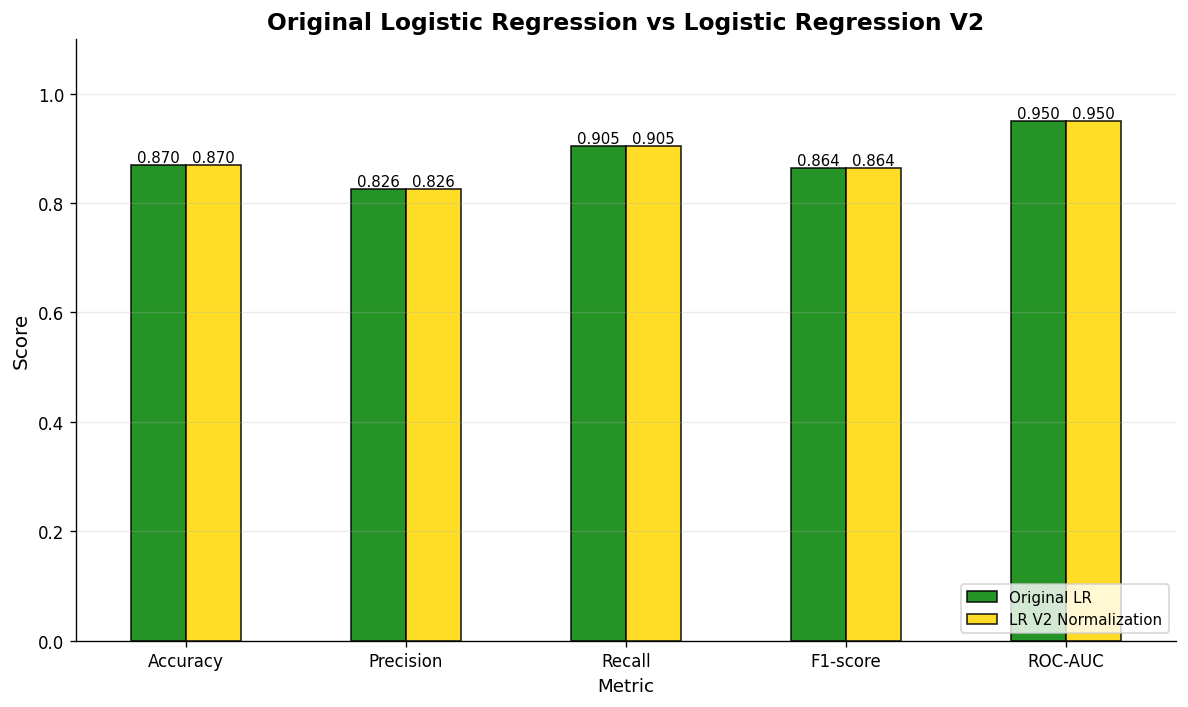

In [31]:
# Cell 31: Compare Original Logistic Regression and Logistic Regression Version 2

# Compare original Logistic Regression and LR V2.
lr_v2_test_metrics = {
    "Accuracy": accuracy_score(y_test, lr_v2_test_pred),
    "Precision": precision_score(y_test, lr_v2_test_pred),
    "Recall": recall_score(y_test, lr_v2_test_pred),
    "F1-score": f1_score(y_test, lr_v2_test_pred),
    "ROC-AUC": roc_auc_score(y_test, lr_v2_test_prob)
}

lr_v2_comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Original LR": [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    "LR V2 Normalization": [
        lr_v2_test_metrics["Accuracy"],
        lr_v2_test_metrics["Precision"],
        lr_v2_test_metrics["Recall"],
        lr_v2_test_metrics["F1-score"],
        lr_v2_test_metrics["ROC-AUC"]
    ]
})

print("Comparison of the original Logistic Regression and Logistic Regression V2:")
display(lr_v2_comparison_df.round(3))

# Plot model comparison.
ax = lr_v2_comparison_df.set_index("Metric").plot(kind="bar", figsize=(10, 6), edgecolor="black", alpha=0.85, color=["green", "gold"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)

plt.title("Original Logistic Regression vs Logistic Regression V2", fontsize=14, fontweight="bold")
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
tidy_axis(ax, grid_axis="y")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Fitting 1 folds for each of 10 candidates, totalling 10 fits
Best L1 Logistic Regression hyperparameters:
{'logistic_regression__C': 1, 'logistic_regression__class_weight': None}
Main explainability comparison table:


,Feature,RF SHAP mean absolute impact,RF LIME local absolute contribution,L1 LR absolute coefficient
1,ca,0.0965,0.2264,1.1594
3,cp,0.0866,0.1631,0.4943
10,thal,0.0758,0.1511,0.6177
6,oldpeak,0.0625,0.0280,0.3091
8,sex,0.0371,0.0734,0.5171
11,thalach,0.0354,0.0186,0.3589
4,exang,0.0313,0.0591,0.4303
0,age,0.0270,0.0360,0.0000
9,slope,0.0232,0.0453,0.2445
2,chol,0.0173,0.0177,0.1535


Evaluation support table:


,Feature,RF SHAP mean signed impact,RF LIME local signed contribution,L1 LR signed coefficient,RF SHAP rank,RF LIME rank,L1 LR coefficient rank
1,ca,0.0033,-0.2264,1.1594,1,1,1
3,cp,0.0077,-0.1631,0.4943,2,2,4
10,thal,0.0091,0.1511,0.6177,3,3,2
6,oldpeak,-0.0023,0.0280,0.3091,4,10,8
8,sex,-0.0101,0.0734,0.5171,5,4,3
11,thalach,0.0052,-0.0186,-0.3589,6,11,6
4,exang,0.0071,-0.0591,0.4303,7,5,5
0,age,0.0071,-0.0360,0.0000,8,8,13
9,slope,0.0010,-0.0453,0.2445,9,6,9
2,chol,-0.0069,-0.0177,0.1535,10,12,12


L1-normalized absolute importance values used in the graph:


,RF SHAP,RF LIME,L1 Logistic Regression
Feature,,,
chol,0.0326,0.0195,0.0302
age,0.0511,0.0397,0.0000
fbs,0.0082,0.0191,0.0669
trestbps,0.0288,0.0325,0.0454
restecg,0.0322,0.0449,0.0441
slope,0.0438,0.0500,0.0481
thalach,0.0668,0.0206,0.0707
exang,0.0591,0.0652,0.0847
oldpeak,0.1180,0.0309,0.0609


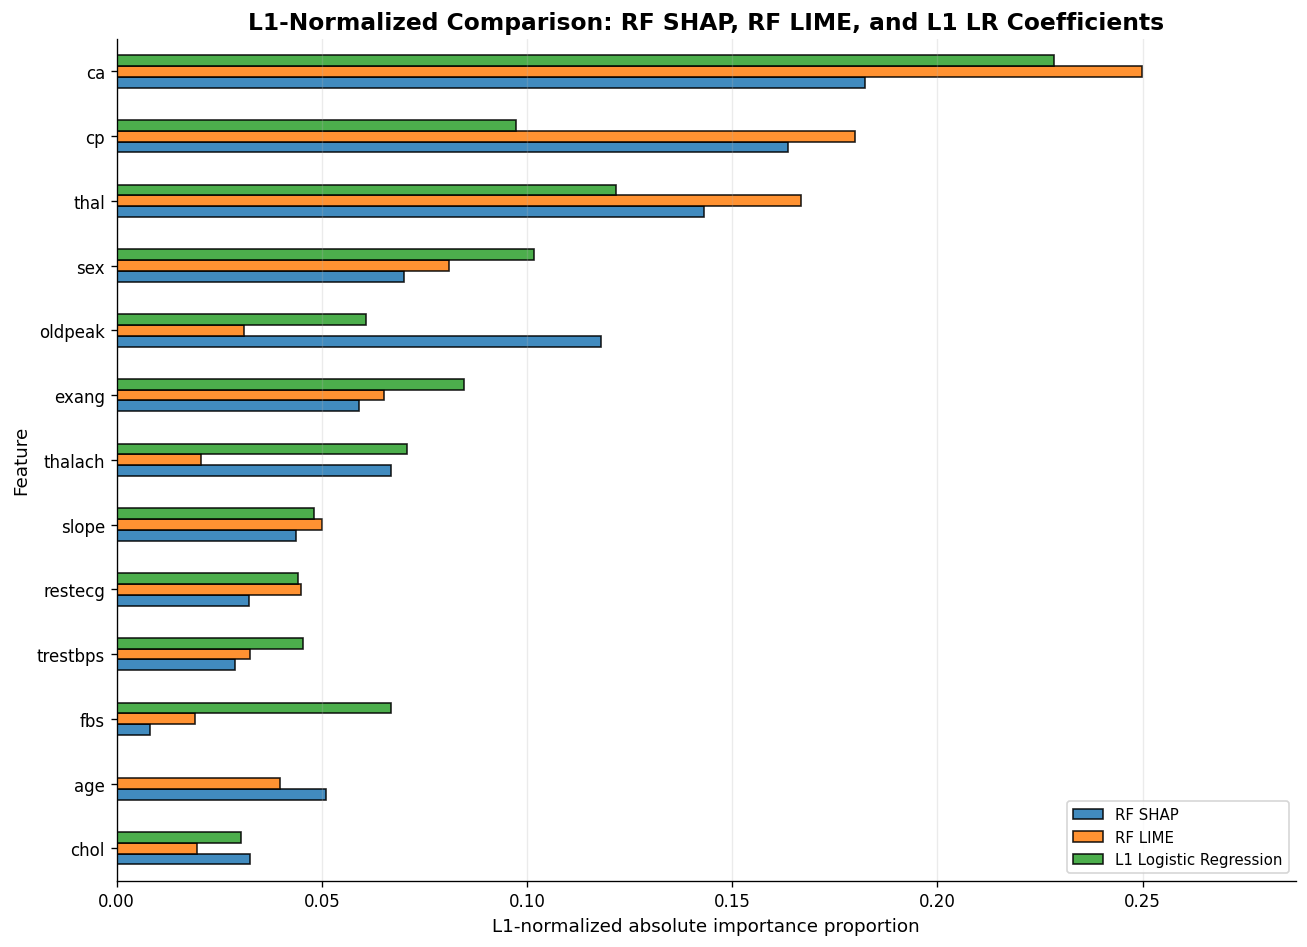

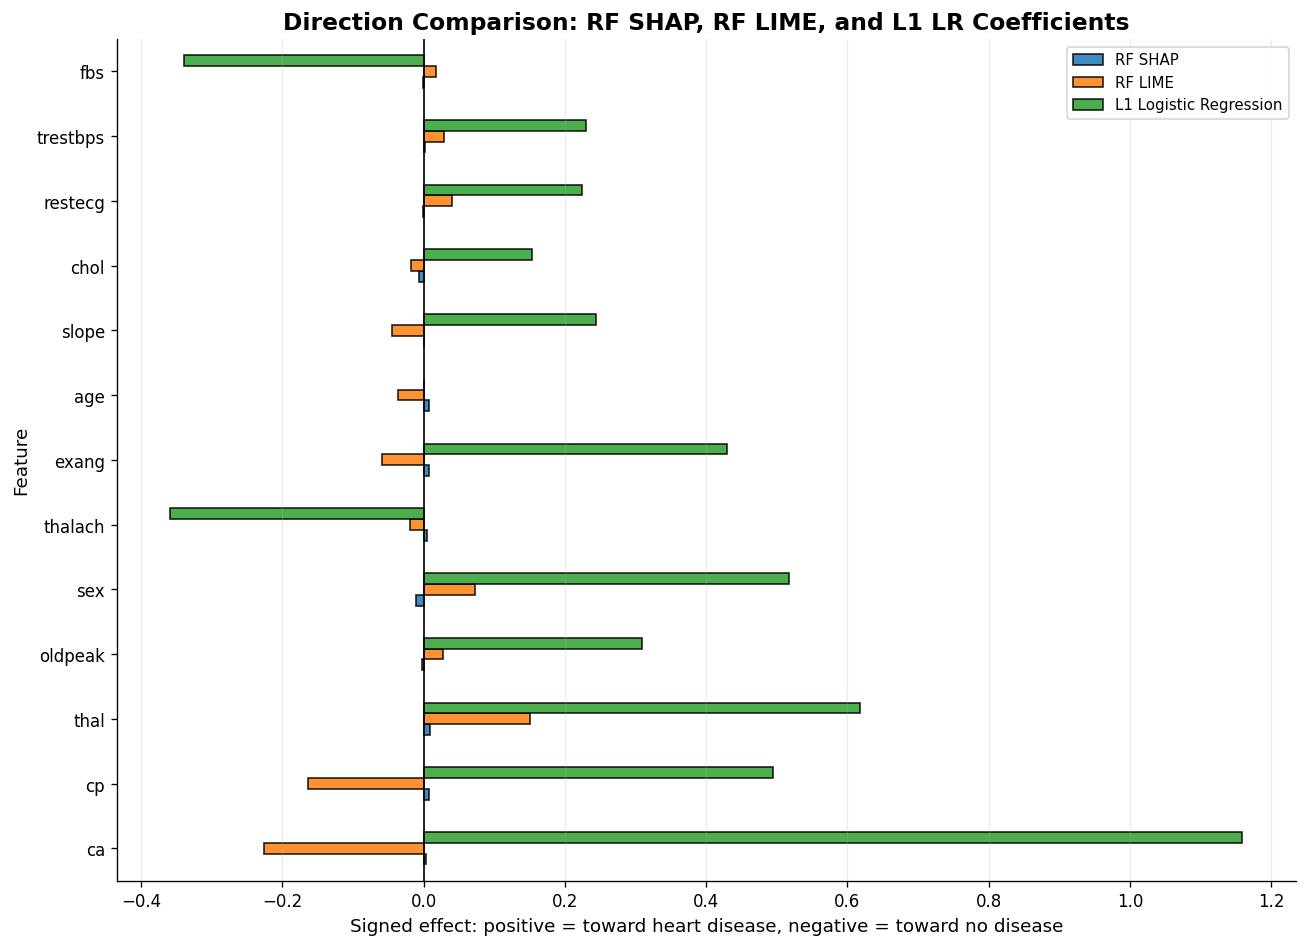

Practical evaluation 1: Feature rank agreement between RF SHAP and RF LIME
Spearman rank correlation (SHAP vs LIME): ρ = 0.714, p = 0.006

Practical evaluation 2: Direction/sign agreement between RF SHAP and RF LIME
Direction agreement: 3/13 features (23%)

Practical evaluation 3: Faithfulness test by cumulative top-k feature ablation
RF baseline accuracy before ablation: 0.826


,Step,SHAP feature ablated,SHAP accuracy,SHAP accuracy drop,LIME feature ablated,LIME accuracy,LIME accuracy drop
0,1,ca,0.826,0.000,ca,0.826,0.000
1,2,cp,0.739,0.087,cp,0.739,0.087
2,3,thal,0.652,0.174,thal,0.652,0.174
3,4,oldpeak,0.543,0.283,sex,0.674,0.152
4,5,sex,0.543,0.283,exang,0.609,0.217


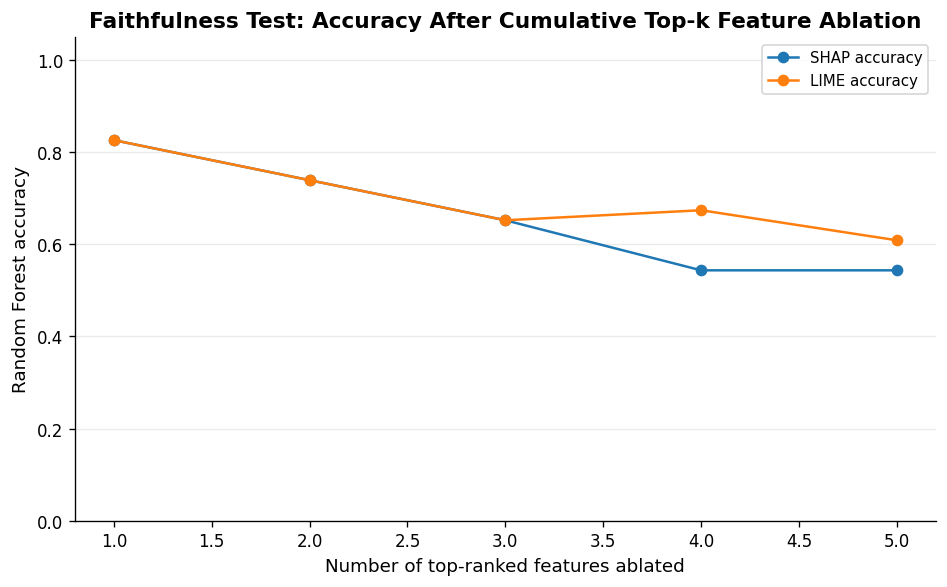

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local


Practical evaluation 4: LIME stability across repeated runs


,Feature,LIME mean contribution,LIME contribution std
5,fbs,0.0140,0.0052
0,age,-0.0354,0.0050
10,thal,0.1478,0.0042
11,thalach,-0.0176,0.0040
4,exang,-0.0639,0.0038
8,sex,0.0781,0.0038
1,ca,-0.2188,0.0036
7,restecg,0.0414,0.0035
6,oldpeak,0.0191,0.0034
3,cp,-0.1712,0.0032


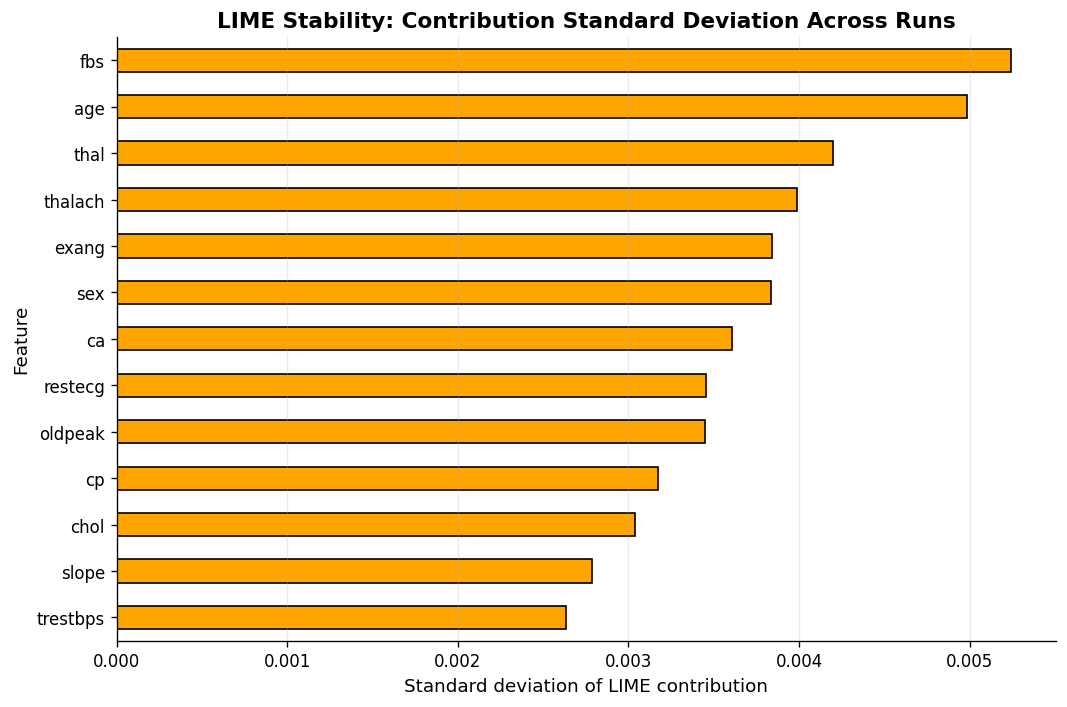

Interpretation notes:
1. RF SHAP is global here and it summarizes average Random Forest impact across the test set.
2. RF LIME is local here and it explains only the selected test patient, so it may differ from global SHAP.
3. Rank agreement checks whether SHAP and LIME prioritize similar features.
4. Sign agreement checks whether SHAP and LIME point in the same direction.
5. Faithfulness checks whether removing top-ranked features damages Random Forest accuracy.
6. Stability checks whether LIME explanations stay similar across repeated runs.


In [37]:
# Cell 32: Compare RF SHAP, RF LIME, and Logistic Regression Coefficients

# 1. Compare RF SHAP, RF LIME, and L1 Logistic Regression feature importance.
# 2. Plot L1-normalized absolute importance values so the three methods use a comparable scale.
# 3. Evaluate explanation quality using rank agreement, sign agreement, faithfulness, and LIME stability.

from scipy.stats import spearmanr

# Helper functions

def match_lime_feature(condition, feature_names):
    """Map a LIME condition such as 'ca <= 0.00' back to the original feature name 'ca'."""
    condition = str(condition)
    for feature in feature_names:
        if condition.startswith(feature) or f" {feature} " in f" {condition} ":
            return feature
    return condition

def l1_normalize_columns(df):
    """L1-normalize each column so every method's values sum to 1."""
    normalized_df = df.copy()
    for col in normalized_df.columns:
        total = normalized_df[col].sum()
        if total != 0:
            normalized_df[col] = normalized_df[col] / total
    return normalized_df

def make_feature_baseline(X_reference):
    """Create neutral replacement values for feature ablation."""
    baseline = {}
    for col in X_reference.columns:
        if pd.api.types.is_numeric_dtype(X_reference[col]):
            baseline[col] = X_reference[col].median()
        else:
            baseline[col] = X_reference[col].mode().iloc[0]
    return baseline

def faithfulness_ablation_scores(model, X_eval, y_eval, feature_ranking, baseline_values, baseline_accuracy, steps=5):
    """Replace top-ranked features with baseline values and measure accuracy drop."""
    scores = []
    X_ablated = X_eval.copy()

    for i, feature in enumerate(feature_ranking[:steps], start=1):
        if feature in X_ablated.columns:
            X_ablated[feature] = baseline_values[feature]

        accuracy = accuracy_score(y_eval, model.predict(X_ablated))
        scores.append({
            "Step": i,
            "Feature ablated": feature,
            "Accuracy after ablation": accuracy,
            "Accuracy drop": baseline_accuracy - accuracy
        })

    return pd.DataFrame(scores)


# 1. Train L1 Logistic Regression for coefficient comparison

lr_l1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=1000
    ))
])

lr_l1_param_grid = {
    "logistic_regression__C": [0.01, 0.1, 1, 10, 100],
    "logistic_regression__class_weight": [None, "balanced"]
}

lr_l1_grid_search = GridSearchCV(
    estimator=lr_l1_pipeline,
    param_grid=lr_l1_param_grid,
    scoring="recall",
    cv=ps,
    n_jobs=-1,
    verbose=1
)

lr_l1_grid_search.fit(X_trainval, y_trainval)
best_lr_l1 = lr_l1_grid_search.best_estimator_
lr_l1_model = best_lr_l1.named_steps["logistic_regression"]

lr_l1_coef_df = pd.DataFrame({
    "Feature": X_trainval.columns,
    "L1 LR signed coefficient": lr_l1_model.coef_[0],
    "L1 LR absolute coefficient": np.abs(lr_l1_model.coef_[0])
})

print("Best L1 Logistic Regression hyperparameters:")
print(lr_l1_grid_search.best_params_)


# 2. Build SHAP, LIME, and L1 LR comparison tables

rf_shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "RF SHAP mean absolute impact": np.abs(shap_exp_plot.values).mean(axis=0),
    "RF SHAP mean signed impact": shap_exp_plot.values.mean(axis=0)
})

rf_lime_importance = lime_table.copy()
rf_lime_importance["Feature"] = rf_lime_importance["Feature condition"].apply(
    lambda text: match_lime_feature(text, X_train.columns)
)

rf_lime_importance = (
    rf_lime_importance
    .groupby("Feature", as_index=False)
    .agg({
        "Contribution": "sum",
        "Absolute contribution": "sum"
    })
    .rename(columns={
        "Contribution": "RF LIME local signed contribution",
        "Absolute contribution": "RF LIME local absolute contribution"
    })
)

explainability_comparison_df = (
    rf_shap_importance
    .merge(rf_lime_importance, on="Feature", how="outer")
    .merge(lr_l1_coef_df, on="Feature", how="outer")
    .fillna(0)
)

explainability_comparison_df["RF SHAP rank"] = (
    explainability_comparison_df["RF SHAP mean absolute impact"]
    .rank(ascending=False, method="min")
    .astype(int)
)

explainability_comparison_df["RF LIME rank"] = (
    explainability_comparison_df["RF LIME local absolute contribution"]
    .rank(ascending=False, method="min")
    .astype(int)
)

explainability_comparison_df["L1 LR coefficient rank"] = (
    explainability_comparison_df["L1 LR absolute coefficient"]
    .rank(ascending=False, method="min")
    .astype(int)
)

explainability_comparison_df = explainability_comparison_df.sort_values("RF SHAP rank")

main_comparison_df = explainability_comparison_df[[
    "Feature",
    "RF SHAP mean absolute impact",
    "RF LIME local absolute contribution",
    "L1 LR absolute coefficient"
]].copy()

evaluation_support_df = explainability_comparison_df[[
    "Feature",
    "RF SHAP mean signed impact",
    "RF LIME local signed contribution",
    "L1 LR signed coefficient",
    "RF SHAP rank",
    "RF LIME rank",
    "L1 LR coefficient rank"
]].copy()

print("Main explainability comparison table:")
display(main_comparison_df.round(4))

print("Evaluation support table:")
display(evaluation_support_df.round(4))

# 3. L1-normalized absolute importance graph

plot_compare_df = main_comparison_df.set_index("Feature").rename(columns={
    "RF SHAP mean absolute impact": "RF SHAP",
    "RF LIME local absolute contribution": "RF LIME",
    "L1 LR absolute coefficient": "L1 Logistic Regression"
})

plot_compare_df = l1_normalize_columns(plot_compare_df)
plot_compare_df["Average normalized importance"] = plot_compare_df.mean(axis=1)
plot_compare_df = (
    plot_compare_df
    .sort_values("Average normalized importance", ascending=True)
    .drop(columns="Average normalized importance")
)

print("L1-normalized absolute importance values used in the graph:")
display(plot_compare_df.round(4))

ax = plot_compare_df.plot(
    kind="barh",
    figsize=(11, 8),
    edgecolor="black",
    alpha=0.85
)
plt.title("L1-Normalized Comparison: RF SHAP, RF LIME, and L1 LR Coefficients", fontsize=14, fontweight="bold")
plt.xlabel("L1-normalized absolute importance proportion")
plt.ylabel("Feature")
plt.xlim(0, min(1.0, max(plot_compare_df.max()) * 1.15))
tidy_axis(ax, grid_axis="x")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 4. Signed direction comparison graph

signed_compare_df = explainability_comparison_df.set_index("Feature")[[
    "RF SHAP mean signed impact",
    "RF LIME local signed contribution",
    "L1 LR signed coefficient"
]].rename(columns={
    "RF SHAP mean signed impact": "RF SHAP",
    "RF LIME local signed contribution": "RF LIME",
    "L1 LR signed coefficient": "L1 Logistic Regression"
})

ax = signed_compare_df.plot(
    kind="barh",
    figsize=(11, 8),
    edgecolor="black",
    alpha=0.85
)
plt.axvline(0, linewidth=1, color="black")
plt.title("Direction Comparison: RF SHAP, RF LIME, and L1 LR Coefficients", fontsize=14, fontweight="bold")
plt.xlabel("Signed effect: positive = toward heart disease, negative = toward no disease")
plt.ylabel("Feature")
tidy_axis(ax, grid_axis="x")
plt.legend(loc="upper right", )
plt.tight_layout()
plt.show()


# 5. Practical evaluation 1: Feature rank agreement

rho, pval = spearmanr(
    explainability_comparison_df["RF SHAP rank"],
    explainability_comparison_df["RF LIME rank"]
)

print("Practical evaluation 1: Feature rank agreement between RF SHAP and RF LIME")
print(f"Spearman rank correlation (SHAP vs LIME): ρ = {rho:.3f}, p = {pval:.3f}")


# 6. Practical evaluation 2: Direction/sign agreement

sign_eval_df = explainability_comparison_df.copy()
nonzero_direction_mask = ~(
    (sign_eval_df["RF SHAP mean signed impact"] == 0) &
    (sign_eval_df["RF LIME local signed contribution"] == 0)
)
sign_eval_df = sign_eval_df.loc[nonzero_direction_mask]

sign_agree = (
    np.sign(sign_eval_df["RF SHAP mean signed impact"]) ==
    np.sign(sign_eval_df["RF LIME local signed contribution"])
)

print("\nPractical evaluation 2: Direction/sign agreement between RF SHAP and RF LIME")
print(f"Direction agreement: {sign_agree.sum()}/{len(sign_agree)} features ({sign_agree.mean() * 100:.0f}%)")


# 7. Practical evaluation 3: Faithfulness ablation test

rf_baseline_accuracy = accuracy_score(y_test, best_rf.predict(X_test))
baseline_values = make_feature_baseline(X_train)

shap_ranking = explainability_comparison_df.sort_values("RF SHAP rank")["Feature"].tolist()
lime_ranking = explainability_comparison_df.sort_values("RF LIME rank")["Feature"].tolist()

shap_faithfulness_df = faithfulness_ablation_scores(
    best_rf, X_test, y_test, shap_ranking, baseline_values, rf_baseline_accuracy, steps=5
)

lime_faithfulness_df = faithfulness_ablation_scores(
    best_rf, X_test, y_test, lime_ranking, baseline_values, rf_baseline_accuracy, steps=5
)

faithfulness_comparison_df = (
    shap_faithfulness_df
    .rename(columns={
        "Feature ablated": "SHAP feature ablated",
        "Accuracy after ablation": "SHAP accuracy",
        "Accuracy drop": "SHAP accuracy drop"
    })
    .merge(
        lime_faithfulness_df.rename(columns={
            "Feature ablated": "LIME feature ablated",
            "Accuracy after ablation": "LIME accuracy",
            "Accuracy drop": "LIME accuracy drop"
        }),
        on="Step",
        how="outer"
    )
)

print("\nPractical evaluation 3: Faithfulness test by cumulative top-k feature ablation")
print(f"RF baseline accuracy before ablation: {rf_baseline_accuracy:.3f}")
display(faithfulness_comparison_df.round(3))

ax = faithfulness_comparison_df.set_index("Step")[["SHAP accuracy", "LIME accuracy"]].plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)
plt.title("Faithfulness Test: Accuracy After Cumulative Top-k Feature Ablation", fontsize=13, fontweight="bold")
plt.xlabel("Number of top-ranked features ablated")
plt.ylabel("Random Forest accuracy")
plt.ylim(0, 1.05)
tidy_axis(ax, grid_axis="y")
plt.tight_layout()
plt.show()

# 8. Practical evaluation 4: LIME stability

n_runs = 10
lime_runs = []

for run_idx in range(n_runs):
    exp = lime_explainer.explain_instance(
        lime_patient.values,
        best_rf.predict_proba,
        num_features=len(X_train.columns)
    )

    run_df = pd.DataFrame(exp.as_list(label=1), columns=["Feature condition", "Contribution"])
    run_df["Feature"] = run_df["Feature condition"].apply(
        lambda text: match_lime_feature(text, X_train.columns)
    )

    lime_runs.append(run_df.groupby("Feature")["Contribution"].sum())

lime_stability_df = pd.concat(lime_runs, axis=1).fillna(0)
lime_stability_df.columns = [f"Run {i + 1}" for i in range(n_runs)]

lime_stability_summary_df = pd.DataFrame({
    "Feature": lime_stability_df.index,
    "LIME mean contribution": lime_stability_df.mean(axis=1).values,
    "LIME contribution std": lime_stability_df.std(axis=1).values
}).sort_values("LIME contribution std", ascending=False)

print("\nPractical evaluation 4: LIME stability across repeated runs")
display(lime_stability_summary_df.round(4))

ax = lime_stability_summary_df.sort_values("LIME contribution std", ascending=True).plot(
    x="Feature",
    y="LIME contribution std",
    kind="barh",
    figsize=(9, 6),
    legend=False,
    edgecolor="black",
    color="orange"
)
plt.title("LIME Stability: Contribution Standard Deviation Across Runs", fontsize=13, fontweight="bold")
plt.xlabel("Standard deviation of LIME contribution")
plt.ylabel("Feature")
tidy_axis(ax, grid_axis="x")
plt.tight_layout()
plt.show()

# 9. Interpretation notes

print("Interpretation notes:")
print("1. RF SHAP is global here and it summarizes average Random Forest impact across the test set.")
print("2. RF LIME is local here and it explains only the selected test patient, so it may differ from global SHAP.")
print("3. Rank agreement checks whether SHAP and LIME prioritize similar features.")
print("4. Sign agreement checks whether SHAP and LIME point in the same direction.")
print("5. Faithfulness checks whether removing top-ranked features damages Random Forest accuracy.")
print("6. Stability checks whether LIME explanations stay similar across repeated runs.")

Model comparison on the same test set:


,Metric,Random Forest,Logistic Regression
0,Accuracy,0.826,0.870
1,Precision,0.783,0.826
2,Recall,0.857,0.905
3,F1-score,0.818,0.864
4,ROC-AUC,0.903,0.950


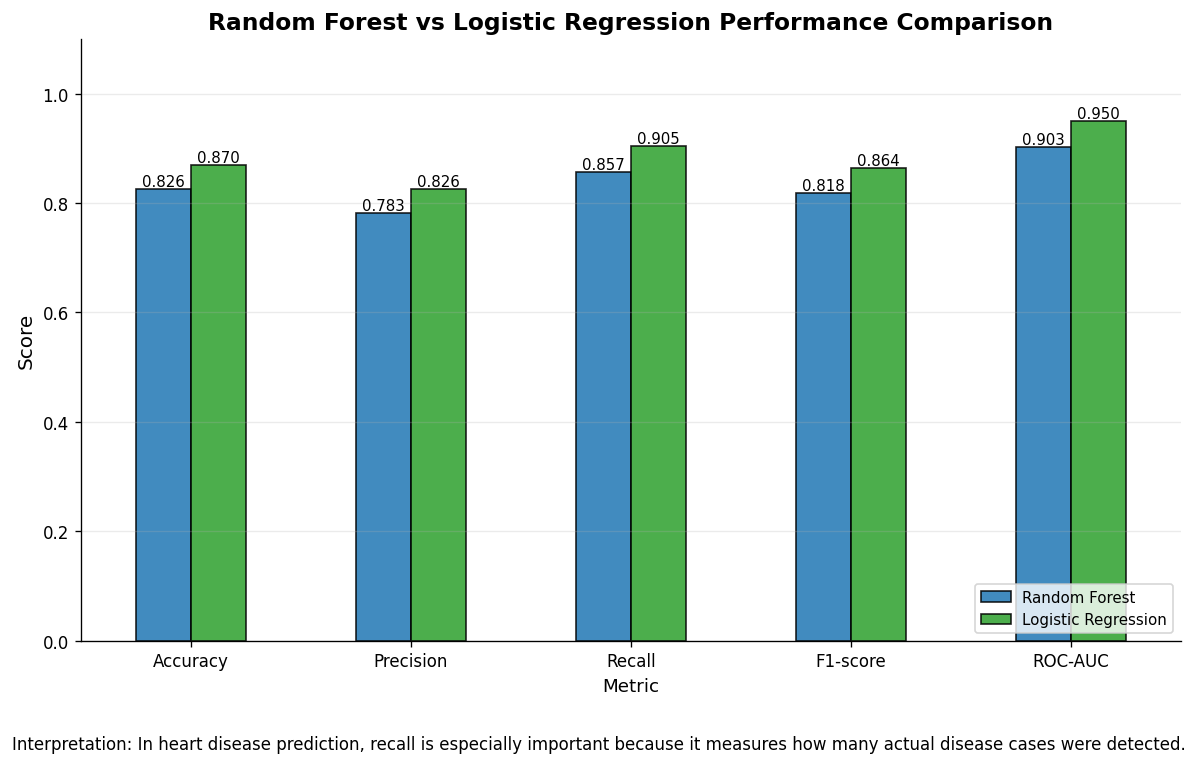

In [33]:
# Cell 33: Compare Random Forest and Logistic Regression Results

# Recalculate Random Forest predictions so comparison does not depend on earlier variable names.
rf_pred_compare = best_rf.predict(X_test)

# Recalculate Random Forest predicted probabilities for the disease class.
rf_prob_compare = best_rf.predict_proba(X_test)[:, 1]

# Calculate Random Forest test metrics.
rf_accuracy = accuracy_score(y_test, rf_pred_compare)
rf_precision = precision_score(y_test, rf_pred_compare)
rf_recall = recall_score(y_test, rf_pred_compare)
rf_f1 = f1_score(y_test, rf_pred_compare)
rf_roc_auc = roc_auc_score(y_test, rf_prob_compare)

# Logistic Regression metrics were already calculated, but they are kept here for a clear comparison table.
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Random Forest": [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc],
    "Logistic Regression": [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc]
})

# Display the comparison table rounded to three decimals.
print("Model comparison on the same test set:")
display(comparison_df.round(3))

# Create a bar chart comparing model performance across metrics.
comparison_plot_df = comparison_df.set_index("Metric")

# Plot grouped bars for easy visual comparison.
# Logistic Regression is shown in green as requested.
ax = comparison_plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black",
    alpha=0.85,
    color={"Random Forest": "tab:blue", "Logistic Regression": "tab:green"}
)

# Add exact values above every bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)

# Add graph title.
plt.title("Random Forest vs Logistic Regression Performance Comparison", fontsize=14, fontweight="bold")

# Add y-axis label.
plt.ylabel("Score", fontsize=12)

# Keep metric names horizontal for readability.
plt.xticks(rotation=0)

# Show y-axis from 0 to 1 because these metrics are proportions.
plt.ylim(0, 1.1)

# Add gridlines for easier comparison.
tidy_axis(ax, grid_axis="y")

# Add legend.
plt.legend(loc="lower right")

# Add an interpretation note.
plt.figtext(
    0.5,
    -0.05,
    "Interpretation: In heart disease prediction, recall is especially important because it measures how many actual disease cases were detected.",
    ha="center",
    fontsize=10
)

# Adjust spacing and show the graph.
plt.tight_layout()
plt.show()


In [34]:
# Cell 34: Final Model Selection and Explainability Summary

# Compare models using recall because this is a medical prediction problem.
# Higher recall means fewer actual heart disease cases are missed.
if rf_recall > lr_recall:
    print("Random Forest has higher recall, so it is better at detecting actual heart disease cases in this test set.")
elif lr_recall > rf_recall:
    print("Logistic Regression has higher recall, so it is better at detecting actual heart disease cases in this test set.")
else:
    print("Both models have the same recall on this test set.")

# Compare ROC-AUC as an overall probability-ranking metric.
if rf_roc_auc > lr_roc_auc:
    print("Random Forest has higher ROC-AUC, meaning it separates disease and no-disease cases better overall.")
elif lr_roc_auc > rf_roc_auc:
    print("Logistic Regression has higher ROC-AUC, meaning it separates disease and no-disease cases better overall.")
else:
    print("Both models have the same ROC-AUC on this test set.")

# Print a note about interpretability.
print("\nInterpretation note:")
print("Random Forest can capture more complex relationships, while Logistic Regression is easier to interpret using coefficients.")
print("RF SHAP gives a global view of Random Forest feature impact across test patients.")
print("RF LIME gives a local waterfall explanation for the selected patient only.")
print("The final comparison table and graphs place RF SHAP, RF LIME, and Logistic Regression coefficients side by side.")
print("For medical prediction, the final model choice should consider recall, ROC-AUC, and explainability together.")


Logistic Regression has higher recall, so it is better at detecting actual heart disease cases in this test set.
Logistic Regression has higher ROC-AUC, meaning it separates disease and no-disease cases better overall.

Interpretation note:
Random Forest can capture more complex relationships, while Logistic Regression is easier to interpret using coefficients.
RF SHAP gives a global view of Random Forest feature impact across test patients.
RF LIME gives a local waterfall explanation for the selected patient only.
The final comparison table and graphs place RF SHAP, RF LIME, and Logistic Regression coefficients side by side.
For medical prediction, the final model choice should consider recall, ROC-AUC, and explainability together.
